# Cancer & Lifestyle Medicine — Comprehensive NHIS 2024 Analysis

This notebook expands the initial demographic analysis to include **lifestyle, behavioral, socioeconomic, and clinical** variables from the NHIS 2024 Adult dataset, covering:

1. **Demographic** — age, sex, race/ethnicity, education, marital status, region, urbanicity, income-to-poverty ratio  
2. **Smoking & tobacco** — ever smoked, current status, cigarette type, e-cigarettes  
3. **Alcohol** — lifetime, past-year, frequency/amount, heavy drinking  
4. **Physical activity** — vigorous/moderate activity, strength training, summary PA categories  
5. **Body weight** — BMI categories  
6. **Sleep** — hours per night  
7. **Mental health** — depression, anxiety  
8. **Chronic conditions** — diabetes, hypertension, heart disease, arthritis, COPD  
9. **Health care access** — insurance coverage, usual place of care  
10. **Self-rated health** — general & household health  
11. **Food security**  
12. **Cancer type breakdown** — specific cancers among survivors  
13. **Multivariate weighted logistic regression** — full lifestyle model  


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('adult24.csv')
print(f"Dataset shape: {df.shape}")


Dataset shape: (32629, 630)


## 2. Variable Extraction & Cleaning

In [2]:
vars_needed = [
    # Identifiers / weights
    'WTFA_A',
    # Demographics
    'AGEP_A', 'SEX_A', 'RACEALLP_A', 'HISPALLP_A', 'EDUCP_A',
    'MARSTAT_A', 'REGION', 'URBRRL23', 'POVRATTC_A',
    # Cancer outcome
    'CANEV_A', 'NUMCAN_A',
    # Specific cancer types
    'BREASCAN_A','PROSTCAN_A','COLONCAN_A','MELANCAN_A','LUNGCAN_A',
    'CERVICAN_A','UTERUCAN_A','OVARYCAN_A','BLADDCAN_A','LEUKECAN_A','LYMPHCAN_A',
    # Smoking
    'SMKEV_A','SMKNOW_A','SMKCIGST_A','ECIGEV_A','ECIGNOW_A','CIGAREV_A',
    # Alcohol
    'DRKLIFE_A','DRKSTAT_A','DRKAVG12M_A','DRKBNG12M_A','DRKHVY12M_A',
    # Physical activity
    'PA18_05R_A', 'PA18_02R_A',
    # BMI
    'BMICAT_A',
    # Sleep
    'SLPHOURS_A',
    # Mental health
    'DEPEV_A','ANXEV_A',
    # Chronic conditions
    'DIBEV_A','HYPEV_A','CHDEV_A','ARTHEV_A','COPDEV_A',
    # Health access
    'HICOV_A','USUALPL_A',
    # Self-rated health
    'PHSTAT_A',
    # Food security
    'FDSCAT4_A',
]

raw = df[vars_needed].copy()
print("Variables extracted:", len(vars_needed))
print(raw.shape)


Variables extracted: 49
(32629, 49)


In [3]:
# ── Label mappings ────────────────────────────────────────────────────────────

cancer_map   = {1:'Yes', 2:'No', 7:'Refused', 8:'Not Ascertained', 9:"Don't Know"}
sex_map      = {1:'Male', 2:'Female', 7:'Refused', 9:"Don't Know"}
race_map     = {1:'White Only',2:'Black/AA Only',3:'AIAN Only',4:'Asian Only',
                5:'NHOPI Only',6:'Multiracial',7:'Other'}
educ_map     = {0:'Never attended', 1:'Grades 1-8',2:'Grades 9-10',3:'Grade 11',
                4:'Grade 12, no diploma',5:'GED/Equiv',6:'HS Diploma',
                7:'Some college, no degree',8:"Associate's",9:"Bachelor's",
                10:"Master's",11:'Professional school',12:'Doctoral',
                97:'Refused',99:"Don't Know"}
educ_grp_map = {0:'< HS', 1:'< HS',2:'< HS',3:'< HS',4:'< HS',
                5:'HS/GED',6:'HS/GED',
                7:'Some College',8:'Some College',
                9:"Bachelor's+",10:"Bachelor's+",11:"Bachelor's+",12:"Bachelor's+",
                97:np.nan,99:np.nan}
marstat_map  = {1:'Married',2:'Widowed',3:'Divorced',4:'Divorced',5:'Separated',
                6:'Never married',7:'Living with partner',8:'Refused',9:"Don't Know"}
region_map   = {1:'Northeast',2:'Midwest',3:'South',4:'West'}
urban_map    = {1:'Large Metro',2:'Small Metro',3:'Micropolitan',4:'Non-metro/Rural'}
smk_map      = {1:'Current (Daily)',2:'Current (Some days)',3:'Former',7:'Refused',8:'N/A',9:"Don't Know"}
ecig_map     = {1:'Yes',2:'No',7:'Refused',9:"Don't Know"}
drk_map      = {1:'Current drinker',2:'Lifetime abstainer',3:'Former drinker',
                4:'Unknown past yr',5:'Unknown',6:'Unknown',7:'Unknown',8:'Unknown',9:'Unknown',10:'Unknown'}
drk_simple   = {1:'Current',2:'Never',3:'Former'}
pa_map       = {1:'Meets both guidelines',2:'Only aerobic',3:'Only strengthening',
                4:'Inactive',8:'Unknown'}
bmi_map      = {1:'Underweight',2:'Healthy weight',3:'Overweight',4:'Obese',9:'Unknown'}
phstat_map   = {1:'Excellent',2:'Very good',3:'Good',4:'Fair',5:'Poor',7:'Refused',9:"Don't Know"}
hicov_map    = {1:'Insured',2:'Uninsured',7:'Refused',9:"Don't Know"}
usualpl_map  = {1:'Yes',2:'No (more than 1 place)',3:'No usual place',7:'Refused',9:"Don't Know"}
dep_map      = {1:'Yes',2:'No',7:'Refused',9:"Don't Know"}
dib_map      = {1:'Yes',2:'No',7:'Refused',9:"Don't Know"}
fds_map      = {1:'Food secure',2:'Marginal food security',
                3:'Low food security',4:'Very low food security',8:'Not applicable'}
yesno_map    = {1:'Yes',2:'No',7:'Refused',9:"Don't Know"}

raw['CANEV_label']   = raw['CANEV_A'].map(cancer_map)
raw['SEX_label']     = raw['SEX_A'].map(sex_map)
raw['RACE_label']    = raw['RACEALLP_A'].map(race_map)
raw['EDUC_grp']      = raw['EDUCP_A'].map(educ_grp_map)
raw['MARSTAT_label'] = raw['MARSTAT_A'].map(marstat_map)
raw['REGION_label']  = raw['REGION'].map(region_map)
raw['URBAN_label']   = raw['URBRRL23'].map(urban_map)
raw['SMKNOW_label']  = raw['SMKNOW_A'].map(smk_map)
raw['ECIG_label']    = raw['ECIGEV_A'].map(ecig_map)
raw['DRK_label']     = raw['DRKSTAT_A'].map(drk_map)
raw['PA_label']      = raw['PA18_05R_A'].map(pa_map)
raw['BMI_label']     = raw['BMICAT_A'].map(bmi_map)
raw['PHSTAT_label']  = raw['PHSTAT_A'].map(phstat_map)
raw['HICOV_label']   = raw['HICOV_A'].map(hicov_map)
raw['USUALPL_label'] = raw['USUALPL_A'].map(usualpl_map)
raw['DEP_label']     = raw['DEPEV_A'].map(dep_map)
raw['ANX_label']     = raw['ANXEV_A'].map(dep_map)
raw['DIB_label']     = raw['DIBEV_A'].map(dib_map)
raw['HYP_label']     = raw['HYPEV_A'].map(yesno_map)
raw['CHD_label']     = raw['CHDEV_A'].map(yesno_map)
raw['ARTH_label']    = raw['ARTHEV_A'].map(yesno_map)
raw['COPD_label']    = raw['COPDEV_A'].map(yesno_map)
raw['FDS_label']     = raw['FDSCAT4_A'].map(fds_map)

# Age groups
raw['AGEGROUP'] = pd.cut(
    raw['AGEP_A'].where(raw['AGEP_A'] < 97),
    bins=[17,29,39,49,59,69,79,120],
    labels=['18-29','30-39','40-49','50-59','60-69','70-79','80+']
)

# Sleep categories  (97=refused, 98=not ascertained, 99=don't know)
valid_sleep = raw['SLPHOURS_A'].where(raw['SLPHOURS_A'] < 20)
# Sleep categories computed with apply below
raw['SLEEP_cat'] = valid_sleep.apply(
    lambda x: '≤5h (Very Short)' if pd.notna(x) and x <= 5
         else ('6h (Short)'       if pd.notna(x) and x == 6
         else ('7-9h (Rec.)'      if pd.notna(x) and 7 <= x <= 9
         else ('≥10h (Long)'      if pd.notna(x) and x >= 10
         else np.nan)))
)

# Poverty ratio categories
raw['POV_cat'] = pd.cut(
    raw['POVRATTC_A'].where(raw['POVRATTC_A'] < 11),
    bins=[0, 1.0, 2.0, 4.0, 99],
    labels=['< 100% FPL','100-199% FPL','200-399% FPL','≥400% FPL'],
    right=True
)

print("Labels created.")
raw[['CANEV_label','SEX_label','RACE_label','EDUC_grp','AGEGROUP']].head()


Labels created.


,CANEV_label,SEX_label,RACE_label,EDUC_grp,AGEGROUP
0,No,Male,White Only,HS/GED,40-49
1,No,Male,White Only,HS/GED,50-59
2,No,Male,White Only,HS/GED,80+
3,No,Male,White Only,< HS,40-49
4,No,Female,Black/AA Only,Bachelor's+,30-39


In [4]:
# Keep only respondents with valid cancer and sex responses
clean = raw[
    raw['CANEV_A'].isin([1, 2]) &
    raw['SEX_A'].isin([1, 2])
].copy()

clean['Cancer'] = (clean['CANEV_A'] == 1).astype(int)

print(f"Clean dataset: {clean.shape}")
print(f"Cancer cases: {clean['Cancer'].sum()}  ({clean['Cancer'].mean()*100:.1f}%)")


Clean dataset: (32594, 76)
Cancer cases: 4434  (13.6%)


## 3. Survey-Weighted Helper Functions

In [5]:
def wt_prev(x, w):
    """Weighted prevalence (proportion)."""
    mask = pd.notna(x) & pd.notna(w)
    return np.sum(w[mask] * x[mask]) / np.sum(w[mask])

def wt_se(x, w):
    """Approximate weighted SE for a proportion."""
    p = wt_prev(x, w)
    mask = pd.notna(x) & pd.notna(w)
    n_eff = np.sum(w[mask])**2 / np.sum(w[mask]**2)
    return np.sqrt(p*(1-p)/n_eff)

def prevalence_table(df, groupvar, outcome='Cancer', weight='WTFA_A'):
    """Return weighted prevalence (%) with 95% CI by group."""
    rows = []
    for grp, sub in df.groupby(groupvar, observed=True):
        x = sub[outcome]
        w = sub[weight]
        p  = wt_prev(x, w)
        se = wt_se(x, w)
        rows.append({'Group': grp,
                     'N': len(sub),
                     'Prevalence': p*100,
                     'CI_low':  max(0,(p - 1.96*se))*100,
                     'CI_high': (p + 1.96*se)*100})
    return pd.DataFrame(rows).set_index('Group')

def plot_prevalence(tbl, title, xlabel='', figsize=(9,5), palette='Blues_d',
                    annotate=True, show_n=True):
    """Horizontal bar chart of weighted cancer prevalence with 95% CI and sample sizes."""
    fig, ax = plt.subplots(figsize=figsize)
    colors = sns.color_palette(palette, len(tbl))
    ax.barh(tbl.index, tbl['Prevalence'], color=colors, edgecolor='white')
    ax.errorbar(tbl['Prevalence'], range(len(tbl)),
                xerr=[tbl['Prevalence']-tbl['CI_low'],
                      tbl['CI_high']-tbl['Prevalence']],
                fmt='none', color='black', capsize=4, linewidth=1.5)
    if annotate:
        for i, (v, lo, hi, n) in enumerate(zip(
                tbl['Prevalence'], tbl['CI_low'], tbl['CI_high'], tbl['N'])):
            label = f'{v:.1f}%'
            if show_n:
                label += f'  (n={n:,})'
            ax.text(v + 0.15, i, label, va='center', fontsize=8.5)
    x_max = (tbl['CI_high'].max() * 1.35) if show_n else (tbl['CI_high'].max() * 1.15)
    ax.set_xlim(0, max(x_max, tbl['Prevalence'].max() * 1.4))
    ax.set_xlabel(xlabel or 'Weighted Cancer Prevalence (%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    plt.tight_layout()
    plt.show()


## 4. Demographic Factors

### 4a. Age Group

          N  Prevalence     CI_low    CI_high
Group                                        
18-29  4082    0.979046   0.617342   1.340749
30-39  5266    1.961929   1.523178   2.400679
40-49  4544    4.607405   3.892083   5.322727
50-59  4743    9.699612   8.691131  10.708092
60-69  6209   17.536919  16.392685  18.681153
70-79  5089   27.344438  25.891652  28.797223
80+    2611   35.920565  33.703128  38.138003


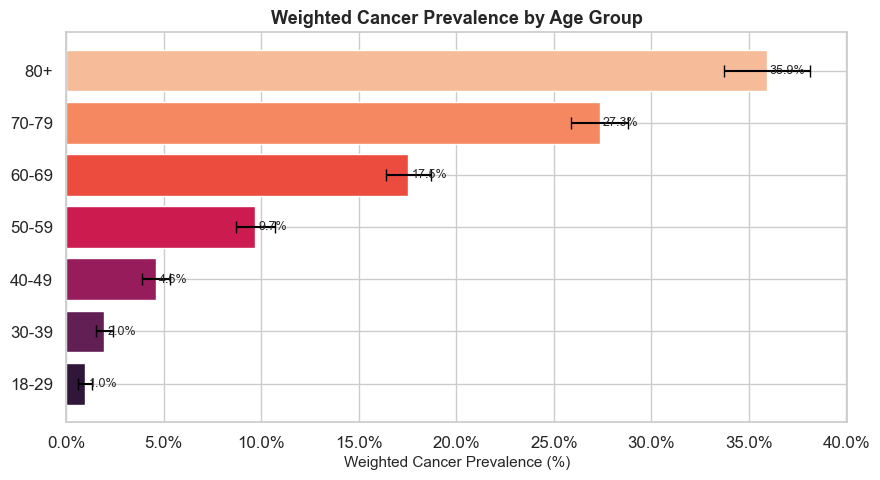

In [6]:
age_tbl = prevalence_table(clean.dropna(subset=['AGEGROUP']), 'AGEGROUP')
print(age_tbl.to_string())
plot_prevalence(age_tbl, 'Weighted Cancer Prevalence by Age Group', palette='rocket')


### 4b. Sex

            N  Prevalence     CI_low    CI_high
Group                                          
Female  17627   10.800334  10.230283  11.370386
Male    14967    9.725889   9.144824  10.306955


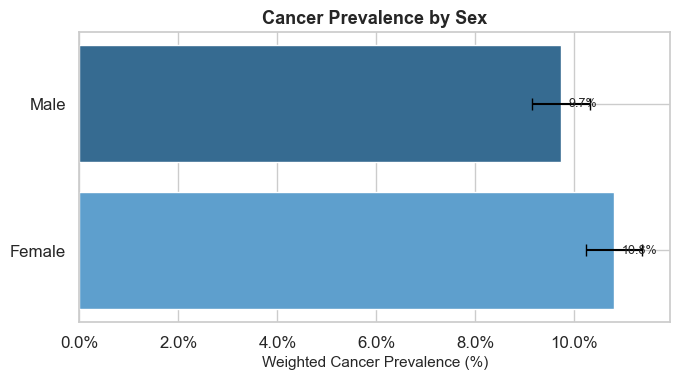

In [7]:
sex_tbl = prevalence_table(clean, 'SEX_label')
print(sex_tbl)
plot_prevalence(sex_tbl, 'Cancer Prevalence by Sex', figsize=(7,4))


### 4c. Race / Ethnicity

                   N  Prevalence     CI_low    CI_high
Group                                                 
Other              7    0.000000   0.000000   0.000000
Multiracial      475    2.879222   1.036097   4.722347
AIAN Only       1893    5.087611   3.904016   6.271207
Black/AA Only   3445    6.410137   5.376174   7.444100
Asian Only       347    9.248783   5.228055  13.269512
NHOPI Only       313   10.962477   6.414488  15.510465
White Only     24422   12.320137  11.813902  12.826371


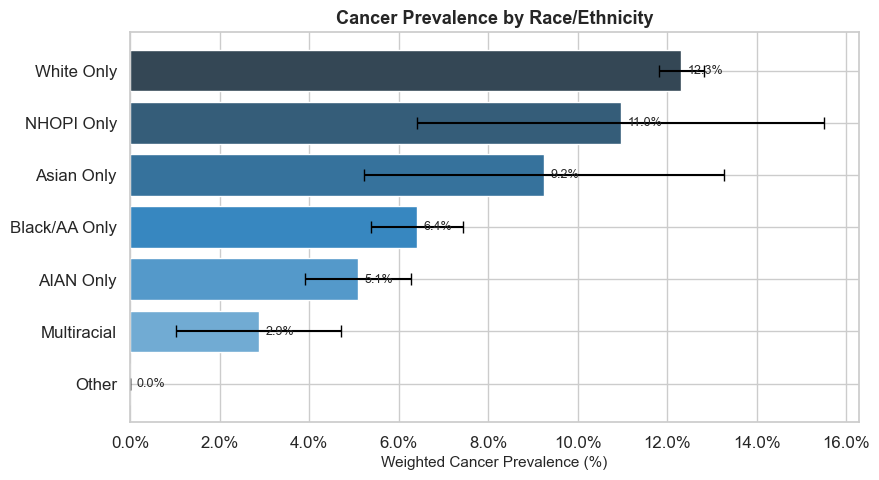

In [8]:
race_tbl = prevalence_table(clean.dropna(subset=['RACE_label']), 'RACE_label')
race_tbl = race_tbl.sort_values('Prevalence')
print(race_tbl.to_string())
plot_prevalence(race_tbl, 'Cancer Prevalence by Race/Ethnicity', figsize=(9,5))


### 4d. Education

                  N  Prevalence     CI_low    CI_high
Group                                                
< HS          11064    9.163263   8.488293   9.838233
HS/GED         6027    9.913066   8.964413  10.861718
Some College  10485   10.842048  10.126457  11.557640
Bachelor's+    4871   13.011522  11.915076  14.107968


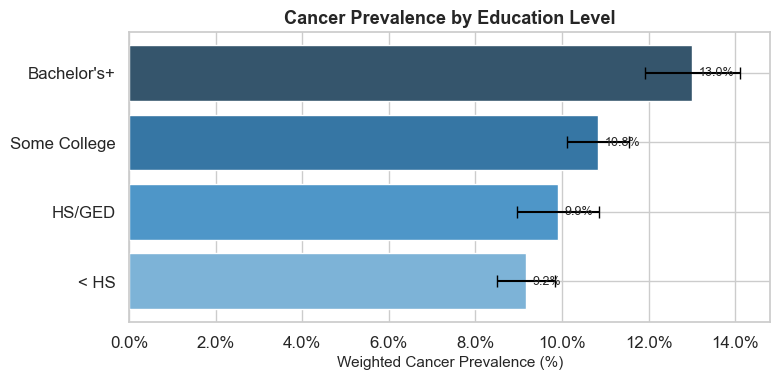

In [9]:
edu_order = ['< HS','HS/GED','Some College',"Bachelor's+"]
edu_tbl = prevalence_table(clean.dropna(subset=['EDUC_grp']), 'EDUC_grp')
edu_tbl = edu_tbl.reindex([x for x in edu_order if x in edu_tbl.index])
print(edu_tbl.to_string())
plot_prevalence(edu_tbl, 'Cancer Prevalence by Education Level', figsize=(8,4))


### 4e. Marital Status

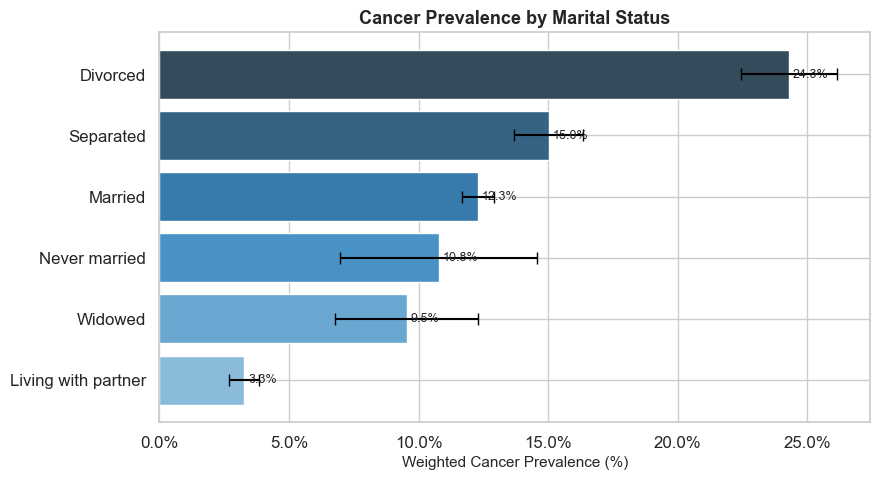

In [10]:
valid_mar = clean[clean['MARSTAT_A'].isin([1,2,3,4,5,6,7])]
mar_tbl = prevalence_table(valid_mar, 'MARSTAT_label')
mar_tbl = mar_tbl.sort_values('Prevalence')
plot_prevalence(mar_tbl, 'Cancer Prevalence by Marital Status', figsize=(9,5))


### 4f. Region & Urbanicity

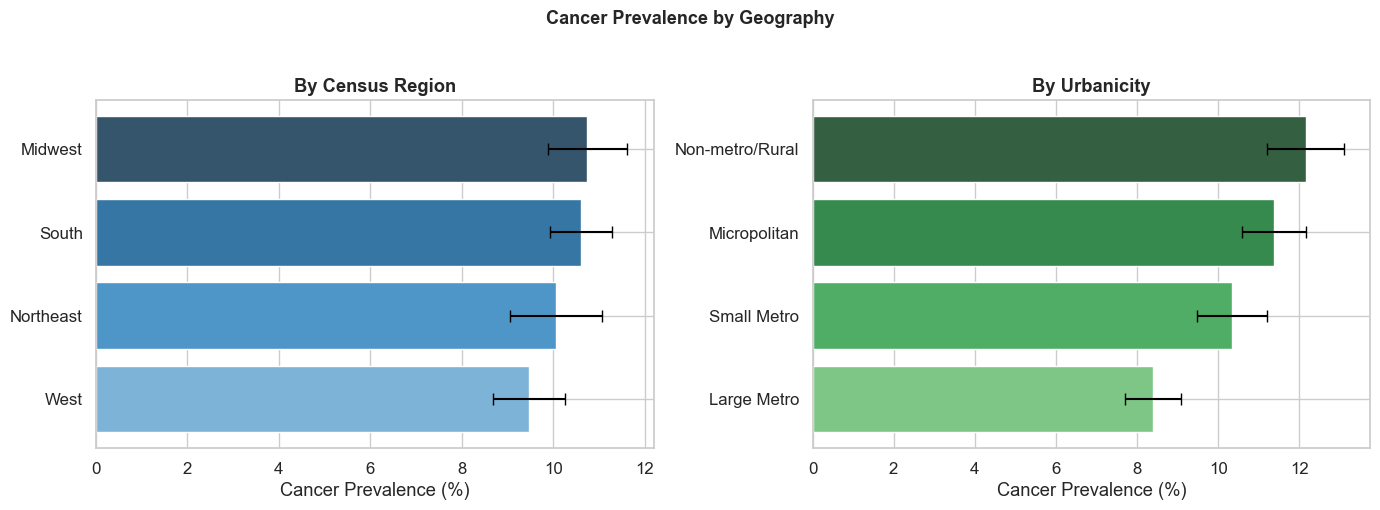

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_tbl = prevalence_table(clean, 'REGION_label').sort_values('Prevalence')
axes[0].barh(reg_tbl.index, reg_tbl['Prevalence'],
             color=sns.color_palette('Blues_d', len(reg_tbl)), edgecolor='white')
axes[0].errorbar(reg_tbl['Prevalence'], range(len(reg_tbl)),
                 xerr=[reg_tbl['Prevalence']-reg_tbl['CI_low'],
                       reg_tbl['CI_high']-reg_tbl['Prevalence']],
                 fmt='none', color='black', capsize=4)
axes[0].set_title('By Census Region', fontweight='bold')
axes[0].set_xlabel('Cancer Prevalence (%)')

urb_tbl = prevalence_table(clean, 'URBAN_label').sort_values('Prevalence')
axes[1].barh(urb_tbl.index, urb_tbl['Prevalence'],
             color=sns.color_palette('Greens_d', len(urb_tbl)), edgecolor='white')
axes[1].errorbar(urb_tbl['Prevalence'], range(len(urb_tbl)),
                 xerr=[urb_tbl['Prevalence']-urb_tbl['CI_low'],
                       urb_tbl['CI_high']-urb_tbl['Prevalence']],
                 fmt='none', color='black', capsize=4)
axes[1].set_title('By Urbanicity', fontweight='bold')
axes[1].set_xlabel('Cancer Prevalence (%)')

plt.suptitle('Cancer Prevalence by Geography', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 4g. Income-to-Poverty Ratio

                  N  Prevalence     CI_low    CI_high
Group                                                
< 100% FPL     3218    7.880026   6.655766   9.104287
100-199% FPL   5762    8.595496   7.663345   9.527647
200-399% FPL   9733   10.424030   9.671983  11.176076
≥400% FPL     11657   11.322374  10.632288  12.012461


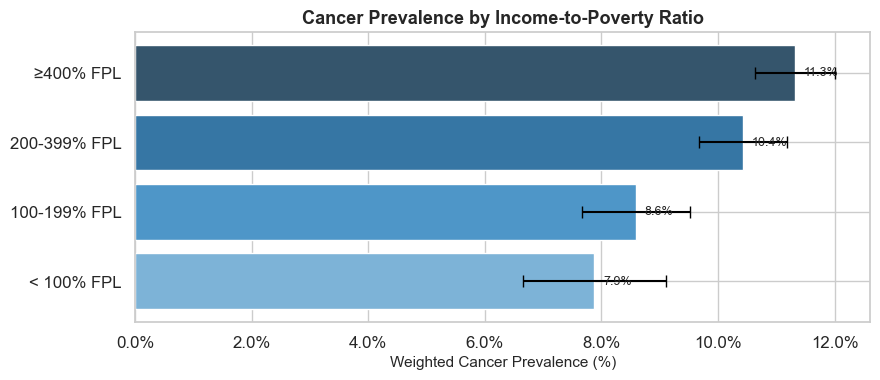

In [12]:
pov_order = ['< 100% FPL','100-199% FPL','200-399% FPL','≥400% FPL']
pov_tbl = prevalence_table(clean.dropna(subset=['POV_cat']), 'POV_cat')
pov_tbl = pov_tbl.reindex([x for x in pov_order if x in pov_tbl.index])
print(pov_tbl.to_string())
plot_prevalence(pov_tbl, 'Cancer Prevalence by Income-to-Poverty Ratio', figsize=(9,4))


## 5. Tobacco Use

                        N  Prevalence     CI_low    CI_high
Group                                                      
Current (Some days)   850    6.811069   4.684463   8.937674
Current (Daily)      2510    9.979665   8.503034  11.456296
Former               8154   16.396957  15.422786  17.371128


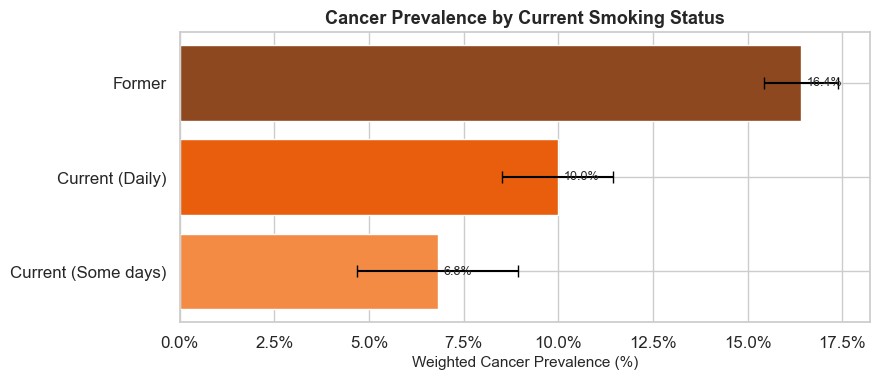

In [13]:
# Ever smoked
ever_smk = clean[clean['SMKEV_A'].isin([1,2])].copy()
ever_smk['EverSmoke'] = (ever_smk['SMKEV_A'] == 1).astype(int)

smk_tbl = prevalence_table(
    clean[clean['SMKNOW_A'].isin([1,2,3])], 'SMKNOW_label'
)
smk_tbl = smk_tbl.sort_values('Prevalence')
print(smk_tbl.to_string())
plot_prevalence(smk_tbl, 'Cancer Prevalence by Current Smoking Status', figsize=(9,4), palette='Oranges_d')


           N  Prevalence     CI_low    CI_high
Group                                         
No     26064   11.539225  11.059917  12.018534
Yes     5794    5.390722   4.676379   6.105064


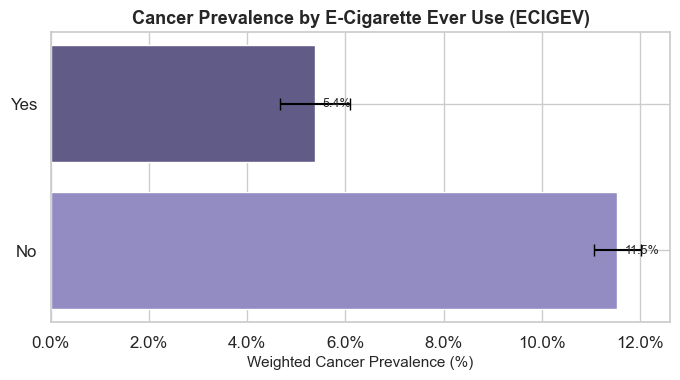

In [14]:
# E-cigarette ever use
ecig_data = clean[clean['ECIGEV_A'].isin([1,2])]
ecig_tbl = prevalence_table(ecig_data, 'ECIG_label')
print(ecig_tbl)
plot_prevalence(ecig_tbl, 'Cancer Prevalence by E-Cigarette Ever Use (ECIGEV)', figsize=(7,4), palette='Purples_d')


## 6. Alcohol Consumption

                       N  Prevalence     CI_low    CI_high
Group                                                     
Current drinker     3720    6.841669   5.815741   7.867597
Lifetime abstainer  3732   14.903864  13.480907  16.326821
Former drinker      2810   16.601228  14.896881  18.305575


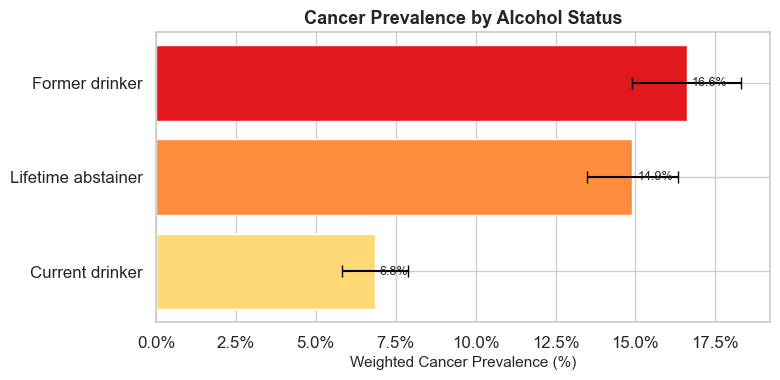

In [15]:
drk_data = clean[clean['DRKSTAT_A'].isin([1,2,3])]
drk_simple_map = {1:'Current drinker', 2:'Lifetime abstainer', 3:'Former drinker'}
drk_data = drk_data.copy()
drk_data['DRK3'] = drk_data['DRKSTAT_A'].map(drk_simple_map)
drk_tbl = prevalence_table(drk_data, 'DRK3').sort_values('Prevalence')
print(drk_tbl)
plot_prevalence(drk_tbl, 'Cancer Prevalence by Alcohol Status', figsize=(8,4), palette='YlOrRd')


                       N  Prevalence     CI_low    CI_high
Group                                                     
Heavy drinker       6940    6.534595   5.830649   7.238541
Not heavy drinker  14492   11.124554  10.497702  11.751407


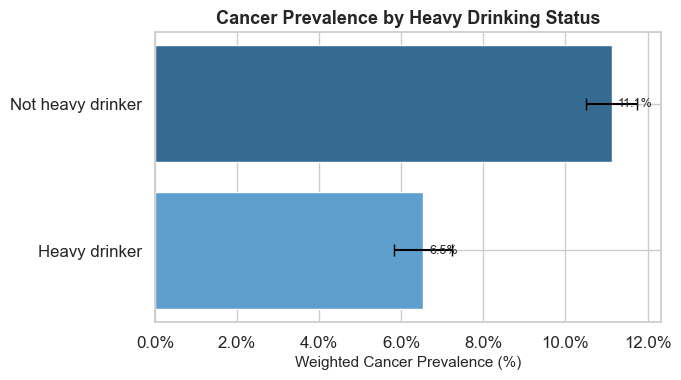

In [16]:
# Heavy drinking (DRKHVY12M_A: 1=Yes, 2=No)
hvy_data = clean[clean['DRKHVY12M_A'].isin([1,2])].copy()
hvy_data['HeavyDrink_label'] = hvy_data['DRKHVY12M_A'].map({1:'Heavy drinker',2:'Not heavy drinker'})
hvy_tbl = prevalence_table(hvy_data, 'HeavyDrink_label').sort_values('Prevalence')
print(hvy_tbl)
plot_prevalence(hvy_tbl, 'Cancer Prevalence by Heavy Drinking Status', figsize=(7,4))


## 7. Physical Activity

⚠️  Unadjusted (confounded by age — see age-stratified plot below)
                           N  Prevalence     CI_low    CI_high
Group                                                         
Meets both guidelines  14545   11.586697  10.940924  12.232471
Only aerobic            2092   11.069794   9.405911  12.733677
Only strengthening      7039   10.061512   9.191936  10.931089
Inactive                7641    7.857639   7.119022   8.596256


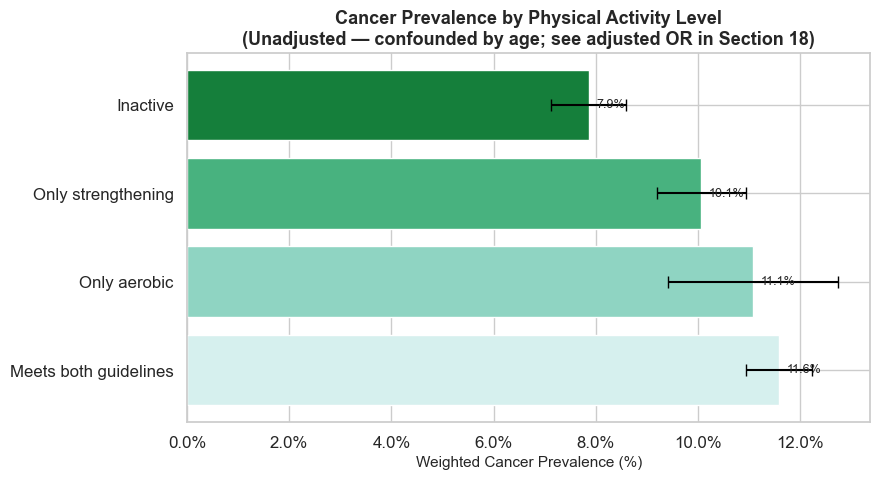


--- Age-stratified PA prevalence (unmasks age confounding) ---


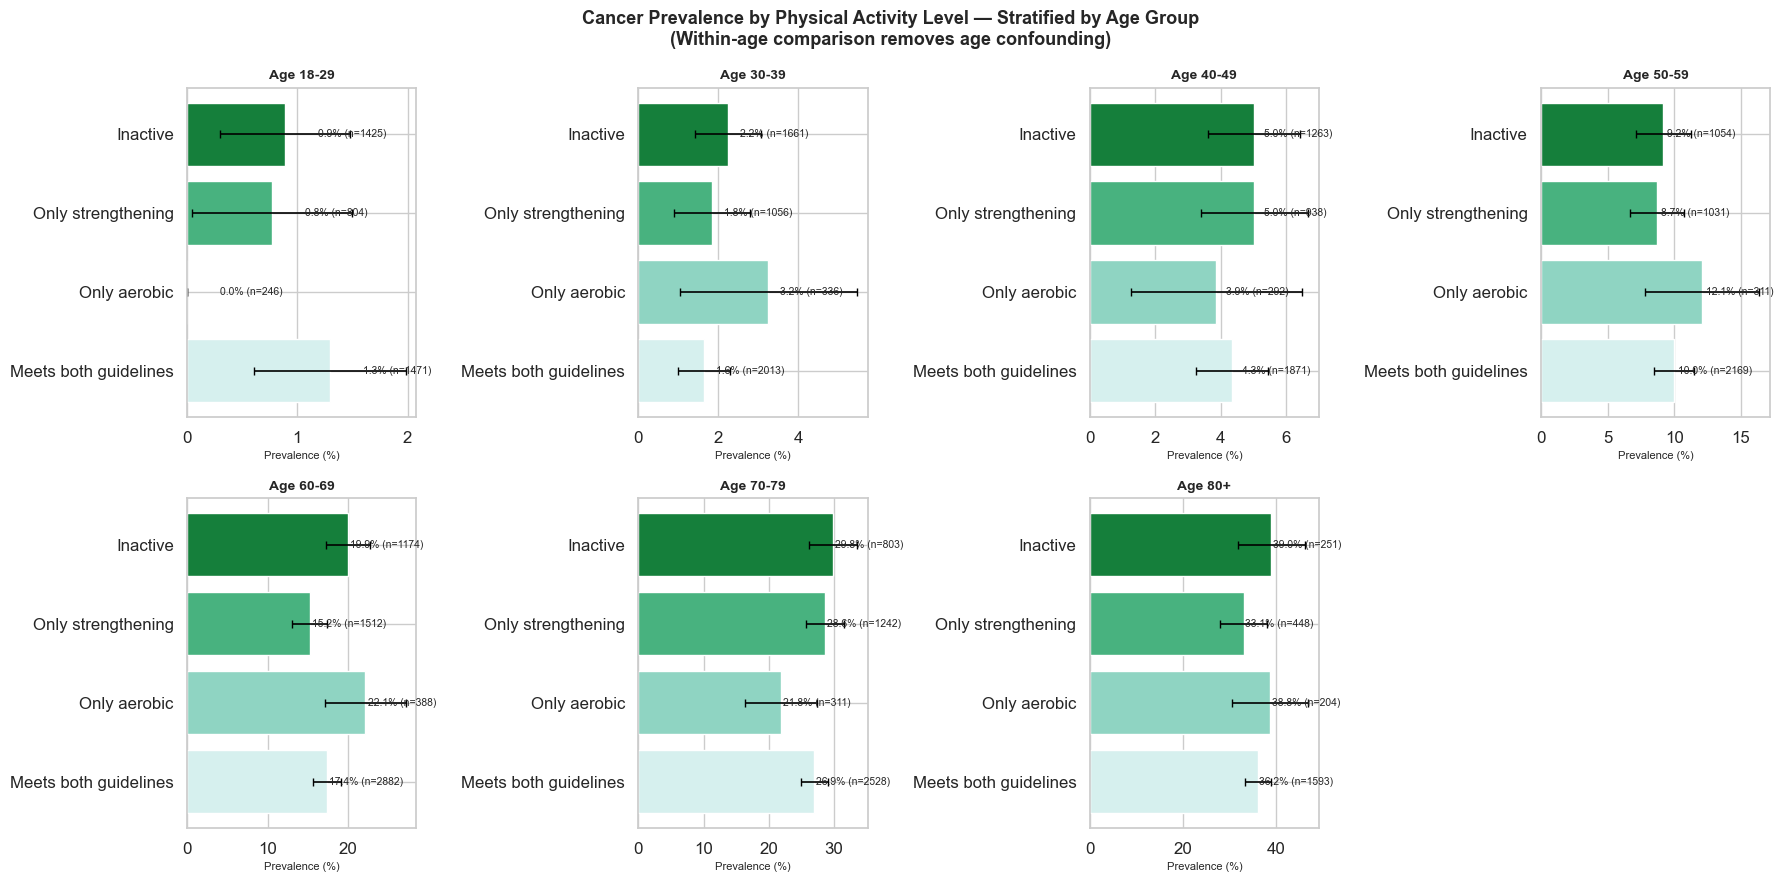


💡 Interpretation: Within each age group, the pattern should be more intuitive.
   The adjusted OR from Section 18 is the authoritative estimate after full adjustment.


In [17]:
# ── 7a. Overall PA prevalence (unadjusted — note caveats below) ──────────────
pa_data = clean[clean['PA18_05R_A'].isin([1,2,3,4])]
pa_order = ['Meets both guidelines','Only aerobic','Only strengthening','Inactive']
pa_tbl = prevalence_table(pa_data, 'PA_label')
pa_tbl = pa_tbl.reindex([x for x in pa_order if x in pa_tbl.index])
print('⚠️  Unadjusted (confounded by age — see age-stratified plot below)')
print(pa_tbl.to_string())
plot_prevalence(pa_tbl,
    'Cancer Prevalence by Physical Activity Level\n(Unadjusted — confounded by age; see adjusted OR in Section 18)',
    figsize=(9,5), palette='BuGn')

# ── 7b. Age-stratified PA prevalence (reveals confounding) ───────────────────
print('\n--- Age-stratified PA prevalence (unmasks age confounding) ---')
age_order = ['18-29','30-39','40-49','50-59','60-69','70-79','80+']
pa_age = pa_data.dropna(subset=['AGEGROUP'])

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=False)
axes = axes.flatten()

for ax, age_grp in zip(axes, age_order):
    sub = pa_age[pa_age['AGEGROUP'] == age_grp]
    if len(sub) < 30:
        ax.set_visible(False)
        continue
    tbl = prevalence_table(sub, 'PA_label')
    tbl = tbl.reindex([x for x in pa_order if x in tbl.index])
    colors = sns.color_palette('BuGn', len(tbl))
    ax.barh(tbl.index, tbl['Prevalence'], color=colors, edgecolor='white')
    ax.errorbar(tbl['Prevalence'], range(len(tbl)),
                xerr=[tbl['Prevalence']-tbl['CI_low'], tbl['CI_high']-tbl['Prevalence']],
                fmt='none', color='black', capsize=3, linewidth=1.2)
    for i, (v, n) in enumerate(zip(tbl['Prevalence'], tbl['N'])):
        ax.text(v + 0.3, i, f'{v:.1f}% (n={n})', va='center', fontsize=7.5)
    ax.set_title(f'Age {age_grp}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Prevalence (%)', fontsize=8)

axes[-1].set_visible(False)
fig.suptitle(
    'Cancer Prevalence by Physical Activity Level — Stratified by Age Group\n'
    '(Within-age comparison removes age confounding)',
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('\n💡 Interpretation: Within each age group, the pattern should be more intuitive.')
print('   The adjusted OR from Section 18 is the authoritative estimate after full adjustment.')


## 8. Body Weight (BMI Category)

                    N  Prevalence     CI_low    CI_high
Group                                                  
Underweight       553   13.332709   9.666458  16.998960
Healthy weight   9987   10.323694   9.577276  11.070113
Overweight      10786   10.715384  10.002379  11.428388
Obese           10679    9.642588   8.952546  10.332630


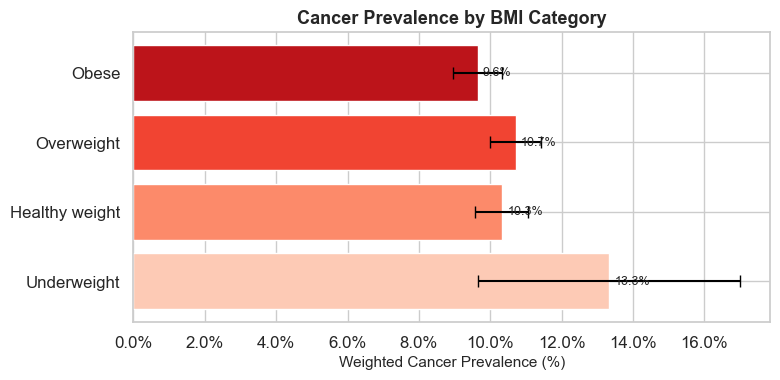

In [18]:
bmi_data = clean[clean['BMICAT_A'].isin([1,2,3,4])]
bmi_order = ['Underweight','Healthy weight','Overweight','Obese']
bmi_tbl = prevalence_table(bmi_data, 'BMI_label')
bmi_tbl = bmi_tbl.reindex([x for x in bmi_order if x in bmi_tbl.index])
print(bmi_tbl.to_string())
plot_prevalence(bmi_tbl, 'Cancer Prevalence by BMI Category', figsize=(8,4), palette='Reds')


## 9. Sleep Duration

                      N  Prevalence     CI_low    CI_high
Group                                                    
≤5h (Very Short)   2907   10.681662   9.267184  12.096140
6h (Short)         6749    9.047674   8.210742   9.884606
7-9h (Rec.)       20586   10.269964   9.757781  10.782146
≥10h (Long)        1212   17.069604  14.385744  19.753463


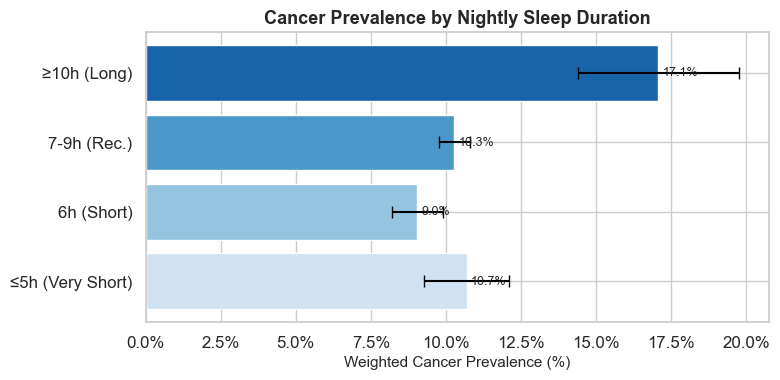

In [19]:
slp_data = clean.dropna(subset=['SLEEP_cat'])
slp_order = ['≤5h (Very Short)','6h (Short)','7-9h (Rec.)','≥10h (Long)']
slp_tbl = prevalence_table(slp_data, 'SLEEP_cat')
slp_tbl = slp_tbl.reindex([x for x in slp_order if x in slp_tbl.index])
print(slp_tbl.to_string())
plot_prevalence(slp_tbl, 'Cancer Prevalence by Nightly Sleep Duration', figsize=(8,4), palette='Blues')


## 10. Mental Health — Depression & Anxiety

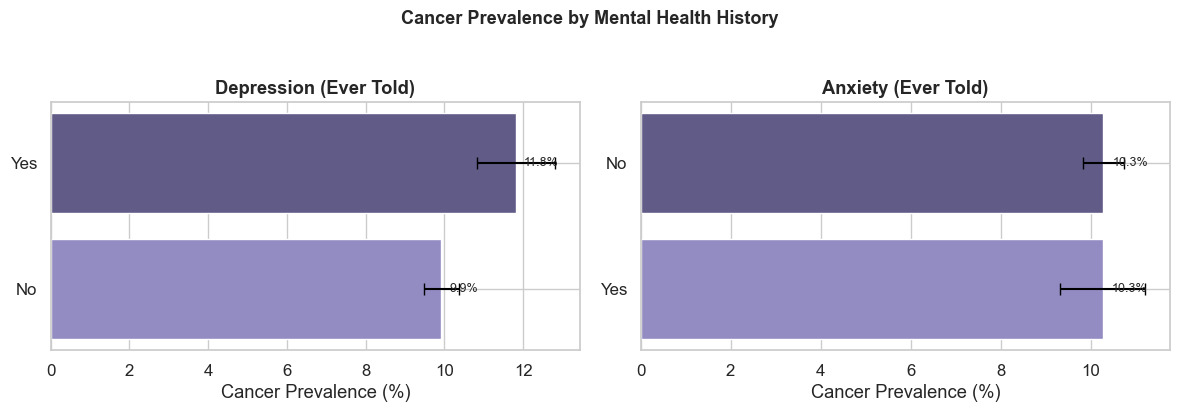

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, lbl, title in [
    (axes[0], 'DEP_label', 'DEPEV_A', 'Depression (Ever Told)'),
    (axes[1], 'ANX_label', 'ANXEV_A', 'Anxiety (Ever Told)'),
]:
    sub = clean[clean[lbl].isin([1,2])].copy()
    tbl = prevalence_table(sub, col)
    tbl = tbl.sort_values('Prevalence')
    ax.barh(tbl.index, tbl['Prevalence'],
            color=sns.color_palette('Purples_d', len(tbl)), edgecolor='white')
    ax.errorbar(tbl['Prevalence'], range(len(tbl)),
                xerr=[tbl['Prevalence']-tbl['CI_low'], tbl['CI_high']-tbl['Prevalence']],
                fmt='none', color='black', capsize=4)
    for i, v in enumerate(tbl['Prevalence']):
        ax.text(v+0.2, i, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cancer Prevalence (%)')

plt.suptitle('Cancer Prevalence by Mental Health History', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


## 11. Comorbid Chronic Conditions

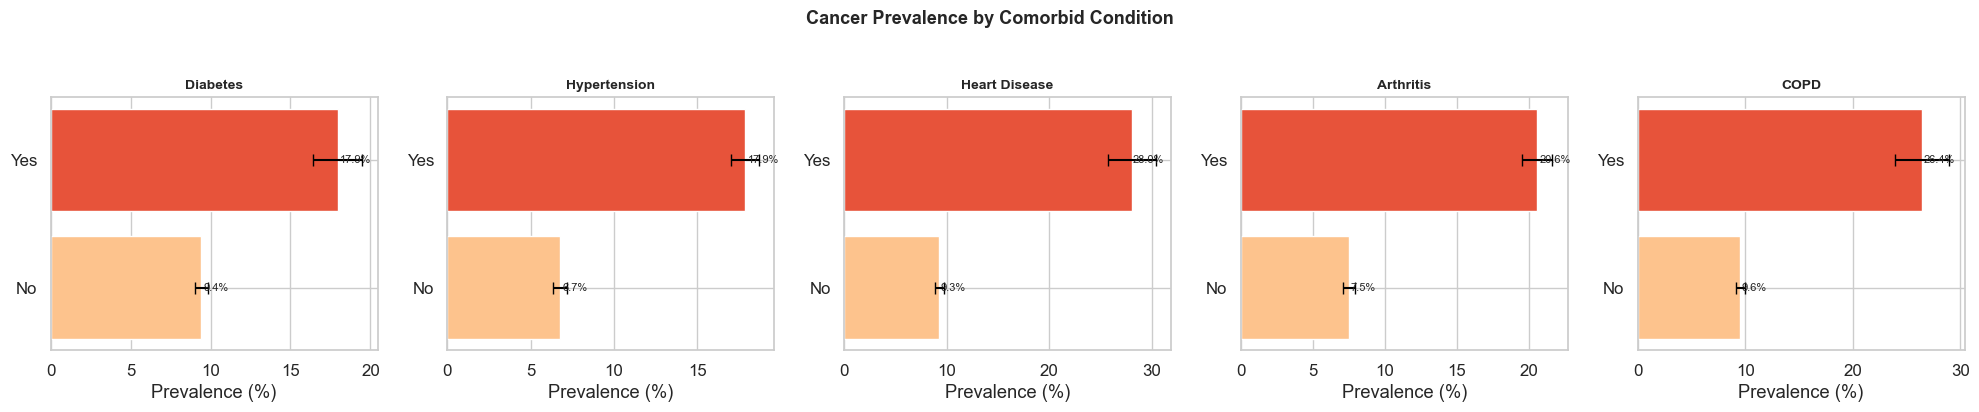

In [21]:
conditions = [
    ('DIB_label',  'DIBEV_A',  'Diabetes'),
    ('HYP_label',  'HYPEV_A',  'Hypertension'),
    ('CHD_label',  'CHDEV_A',  'Heart Disease'),
    ('ARTH_label', 'ARTHEV_A', 'Arthritis'),
    ('COPD_label', 'COPDEV_A', 'COPD'),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)

for ax, (col, code_col, title) in zip(axes, conditions):
    sub = clean[clean[code_col].isin([1,2])]
    tbl = prevalence_table(sub, col).sort_values('Prevalence')
    ax.barh(tbl.index, tbl['Prevalence'],
            color=sns.color_palette('OrRd', len(tbl)), edgecolor='white')
    ax.errorbar(tbl['Prevalence'], range(len(tbl)),
                xerr=[tbl['Prevalence']-tbl['CI_low'], tbl['CI_high']-tbl['Prevalence']],
                fmt='none', color='black', capsize=4)
    for i, v in enumerate(tbl['Prevalence']):
        ax.text(v+0.15, i, f'{v:.1f}%', va='center', fontsize=8)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Prevalence (%)')

plt.suptitle('Cancer Prevalence by Comorbid Condition', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


## 12. Health Insurance & Access to Care

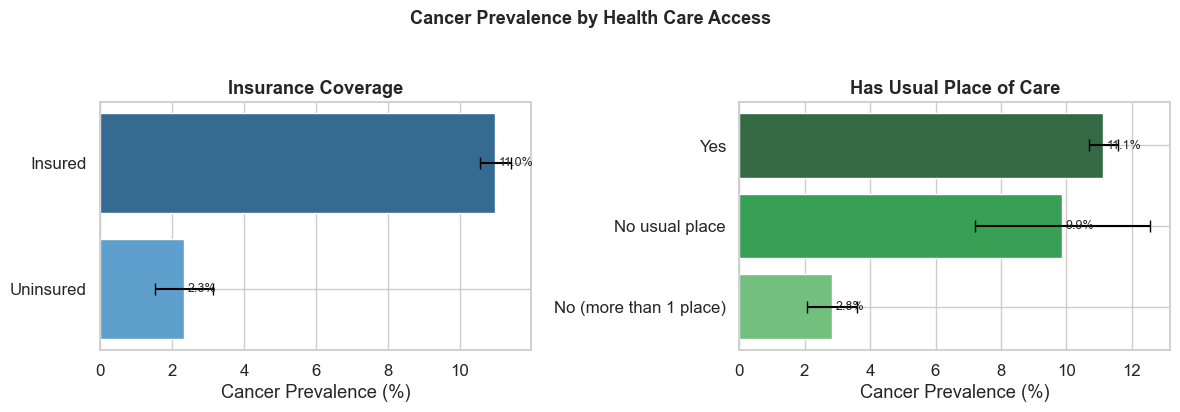

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Insurance
ins_data = clean[clean['HICOV_A'].isin([1,2])]
ins_tbl = prevalence_table(ins_data, 'HICOV_label').sort_values('Prevalence')
axes[0].barh(ins_tbl.index, ins_tbl['Prevalence'],
             color=sns.color_palette('Blues_d', 2), edgecolor='white')
axes[0].errorbar(ins_tbl['Prevalence'], range(len(ins_tbl)),
                 xerr=[ins_tbl['Prevalence']-ins_tbl['CI_low'],
                       ins_tbl['CI_high']-ins_tbl['Prevalence']],
                 fmt='none', color='black', capsize=4)
for i, v in enumerate(ins_tbl['Prevalence']):
    axes[0].text(v+0.1, i, f'{v:.1f}%', va='center', fontsize=9)
axes[0].set_title('Insurance Coverage', fontweight='bold')
axes[0].set_xlabel('Cancer Prevalence (%)')

# Usual place of care
upl_data = clean[clean['USUALPL_A'].isin([1,2,3])]
upl_tbl = prevalence_table(upl_data, 'USUALPL_label').sort_values('Prevalence')
axes[1].barh(upl_tbl.index, upl_tbl['Prevalence'],
             color=sns.color_palette('Greens_d', 3), edgecolor='white')
axes[1].errorbar(upl_tbl['Prevalence'], range(len(upl_tbl)),
                 xerr=[upl_tbl['Prevalence']-upl_tbl['CI_low'],
                       upl_tbl['CI_high']-upl_tbl['Prevalence']],
                 fmt='none', color='black', capsize=4)
for i, v in enumerate(upl_tbl['Prevalence']):
    axes[1].text(v+0.1, i, f'{v:.1f}%', va='center', fontsize=9)
axes[1].set_title('Has Usual Place of Care', fontweight='bold')
axes[1].set_xlabel('Cancer Prevalence (%)')

plt.suptitle('Cancer Prevalence by Health Care Access', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


## 13. Self-Rated General Health

               N  Prevalence     CI_low    CI_high
Group                                             
Excellent   6299    4.735378   4.095448   5.375309
Very good  10906    8.640596   7.994445   9.286748
Good       10026   11.744791  10.962328  12.527254
Fair        4144   16.430711  15.005477  17.855946
Poor        1206   27.188769  24.058217  30.319320


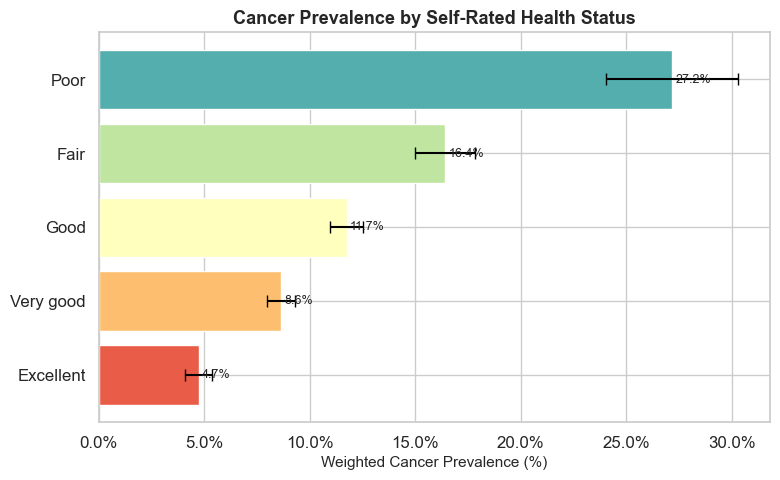

In [23]:
ph_data = clean[clean['PHSTAT_A'].isin([1,2,3,4,5])]
ph_order = ['Excellent','Very good','Good','Fair','Poor']
ph_tbl = prevalence_table(ph_data, 'PHSTAT_label')
ph_tbl = ph_tbl.reindex([x for x in ph_order if x in ph_tbl.index])
print(ph_tbl.to_string())
plot_prevalence(ph_tbl, 'Cancer Prevalence by Self-Rated Health Status', palette='Spectral', figsize=(8,5))


## 14. Food Security

                            N  Prevalence     CI_low    CI_high
Group                                                          
Food secure             26531   10.964111  10.500744  11.427477
Marginal food security   1959    6.460280   5.119444   7.801115
Low food security        1570    7.577988   5.945806   9.210169
Very low food security   1186    7.261320   5.352823   9.169816


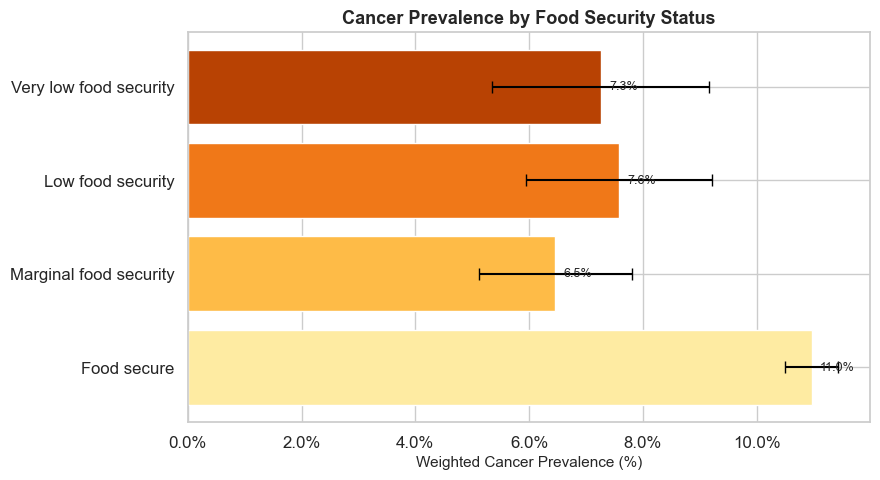

In [24]:
fds_data = clean[clean['FDSCAT4_A'].isin([1,2,3,4])]
fds_order = ['Food secure','Marginal food security','Low food security','Very low food security']
fds_tbl = prevalence_table(fds_data, 'FDS_label')
fds_tbl = fds_tbl.reindex([x for x in fds_order if x in fds_tbl.index])
print(fds_tbl.to_string())
plot_prevalence(fds_tbl, 'Cancer Prevalence by Food Security Status', figsize=(9,5), palette='YlOrBr')


## 15. Cancer Type Breakdown Among Survivors

Cancer survivors in sample: 4434
Cancer Type  Pct of Survivors (%)   n
   Leukemia              1.678766  74
   Lymphoma              3.198730 141
    Bladder              3.266047 144
       Lung              3.289474 145
    Ovarian              3.748489  93
      Colon              4.967113 219
   Melanoma              5.172414 228
    Uterine              5.965337 148
   Cervical              7.053607 175
     Breast             18.421053 812
   Prostate             28.126622 542


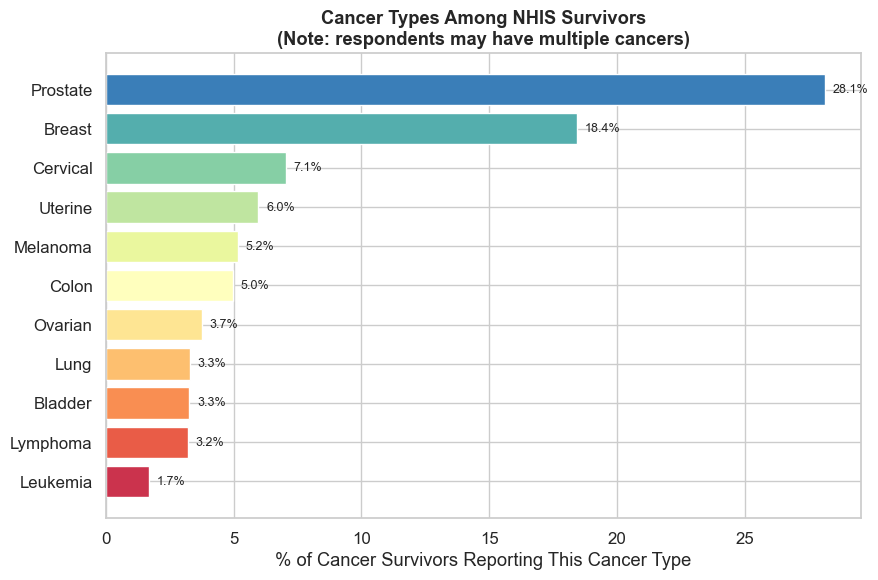

In [25]:
cancer_survivors = clean[clean['CANEV_A'] == 1].copy()
n_surv = len(cancer_survivors)
print(f"Cancer survivors in sample: {n_surv}")

cancer_types = {
    'Breast':     'BREASCAN_A',
    'Prostate':   'PROSTCAN_A',
    'Colon':      'COLONCAN_A',
    'Melanoma':   'MELANCAN_A',
    'Lung':       'LUNGCAN_A',
    'Cervical':   'CERVICAN_A',
    'Uterine':    'UTERUCAN_A',
    'Ovarian':    'OVARYCAN_A',
    'Bladder':    'BLADDCAN_A',
    'Leukemia':   'LEUKECAN_A',
    'Lymphoma':   'LYMPHCAN_A',
}

rows = []
for name, col in cancer_types.items():
    sub = cancer_survivors[cancer_survivors[col].isin([1,2])]
    pct = (sub[col] == 1).sum() / len(sub) * 100 if len(sub) > 0 else np.nan
    rows.append({'Cancer Type': name, 'Pct of Survivors (%)': pct, 'n': (sub[col]==1).sum()})

ct_df = pd.DataFrame(rows).sort_values('Pct of Survivors (%)', ascending=True)
print(ct_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette('Spectral', len(ct_df))
ax.barh(ct_df['Cancer Type'], ct_df['Pct of Survivors (%)'], color=colors, edgecolor='white')
for i, v in enumerate(ct_df['Pct of Survivors (%)']):
    ax.text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('% of Cancer Survivors Reporting This Cancer Type')
ax.set_title('Cancer Types Among NHIS Survivors\n(Note: respondents may have multiple cancers)',
             fontweight='bold')
plt.tight_layout()
plt.show()


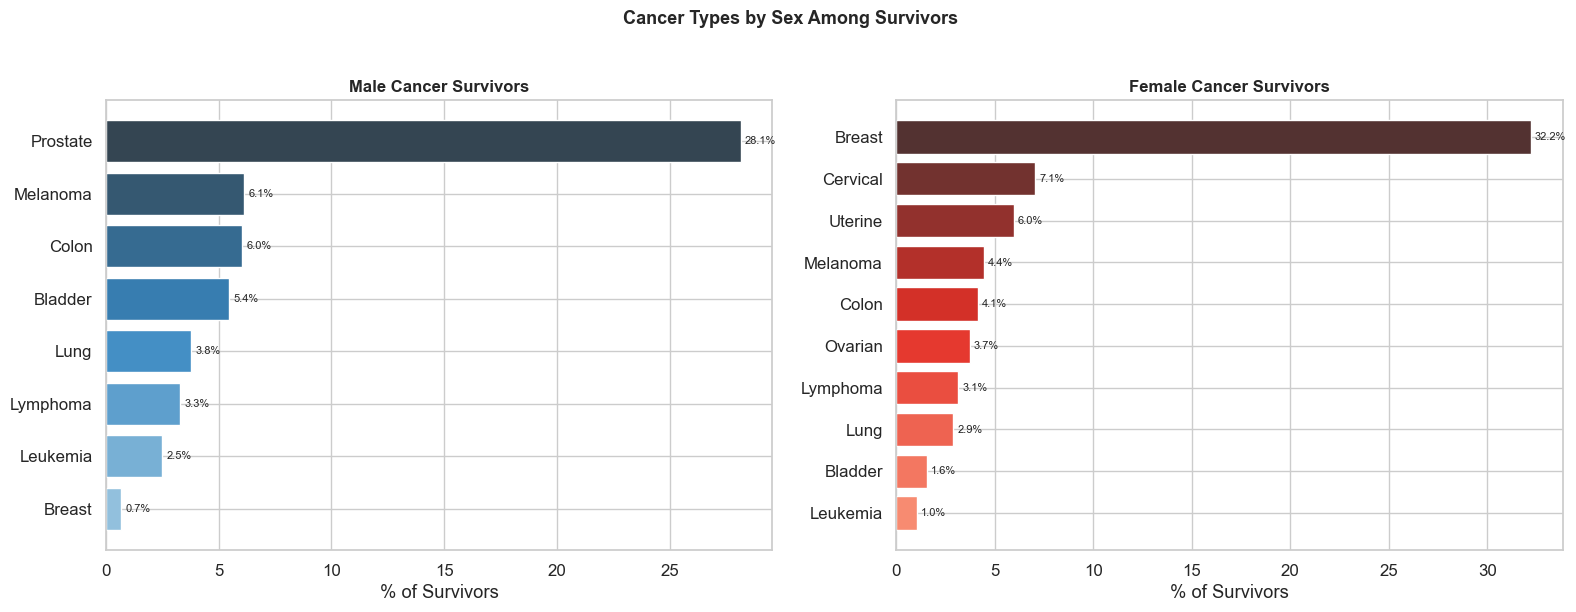

In [26]:
# Sex-stratified cancer types
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (sex_label, sex_code) in zip(axes, [('Male',1),('Female',2)]):
    sub_sex = cancer_survivors[cancer_survivors['SEX_A'] == sex_code]
    rows = []
    for name, col in cancer_types.items():
        sub = sub_sex[sub_sex[col].isin([1,2])]
        if len(sub) > 0:
            pct = (sub[col] == 1).sum() / len(sub) * 100
            rows.append({'Cancer Type': name, 'Pct': pct})
    cdf = pd.DataFrame(rows).sort_values('Pct')
    ax.barh(cdf['Cancer Type'], cdf['Pct'],
            color=sns.color_palette('Blues_d' if sex_code==1 else 'Reds_d', len(cdf)),
            edgecolor='white')
    for i, v in enumerate(cdf['Pct']):
        ax.text(v+0.2, i, f'{v:.1f}%', va='center', fontsize=8)
    ax.set_title(f'{sex_label} Cancer Survivors', fontweight='bold', fontsize=12)
    ax.set_xlabel('% of Survivors')

plt.suptitle('Cancer Types by Sex Among Survivors', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 16. Interaction Heatmaps

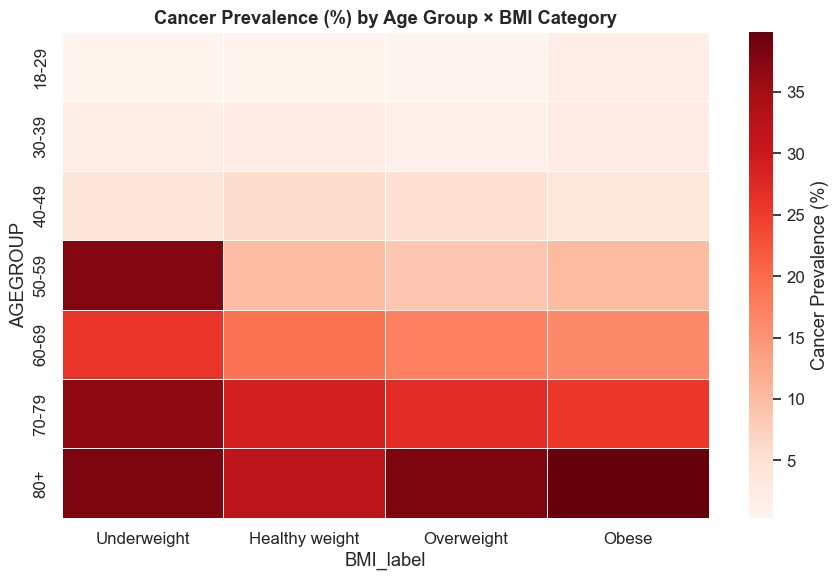

In [35]:
# Age × BMI heatmap
hm_data = clean[clean['BMICAT_A'].isin([1,2,3,4])].dropna(subset=['AGEGROUP','BMI_label'])
bmi_order = ['Underweight','Healthy weight','Overweight','Obese']
age_order = ['18-29','30-39','40-49','50-59','60-69','70-79','80+']

hm = (hm_data.groupby(['AGEGROUP','BMI_label'], observed=True)
      .apply(lambda x: wt_prev(x['Cancer'], x['WTFA_A']))
      .unstack() * 100)
hm = hm.reindex(index=[x for x in age_order if x in hm.index],
                columns=[x for x in bmi_order if x in hm.columns])

plt.figure(figsize=(9, 6))
sns.heatmap(hm, fmt='.1f', cmap='Reds', linewidths=0.5,
            cbar_kws={'label': 'Cancer Prevalence (%)'})
plt.title('Cancer Prevalence (%) by Age Group × BMI Category', fontweight='bold')
plt.tight_layout()
plt.show()


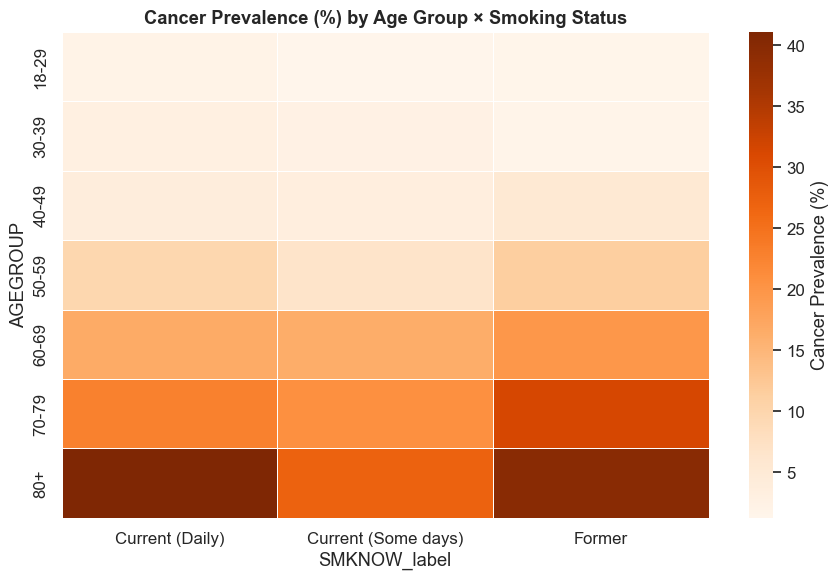

In [36]:
# Age × Smoking heatmap
smk_data = clean[clean['SMKNOW_A'].isin([1,2,3])].dropna(subset=['AGEGROUP','SMKNOW_label'])
hm2 = (smk_data.groupby(['AGEGROUP','SMKNOW_label'], observed=True)
       .apply(lambda x: wt_prev(x['Cancer'], x['WTFA_A']))
       .unstack() * 100)
age_order_present = [x for x in age_order if x in hm2.index]
hm2 = hm2.reindex(index=age_order_present)

plt.figure(figsize=(9, 6))
sns.heatmap(hm2, fmt='.1f', cmap='Oranges', linewidths=0.5,
            cbar_kws={'label': 'Cancer Prevalence (%)'})
plt.title('Cancer Prevalence (%) by Age Group × Smoking Status', fontweight='bold')
plt.tight_layout()
plt.show()


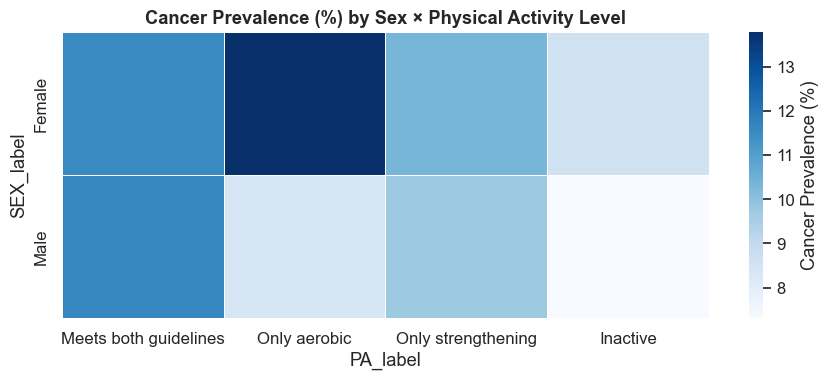

In [37]:
# Sex × PA heatmap
pa_hm_data = clean[clean['PA18_05R_A'].isin([1,2,3,4])]
hm3 = (pa_hm_data.groupby(['SEX_label','PA_label'], observed=True)
       .apply(lambda x: wt_prev(x['Cancer'], x['WTFA_A']))
       .unstack() * 100)
pa_order_present = [x for x in pa_order if x in hm3.columns]
hm3 = hm3[pa_order_present]

plt.figure(figsize=(9, 4))
sns.heatmap(hm3, fmt='.1f', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Cancer Prevalence (%)'})
plt.title('Cancer Prevalence (%) by Sex × Physical Activity Level', fontweight='bold')
plt.tight_layout()
plt.show()


## 17. Comprehensive Summary Statistics Table

In [30]:
summary_rows = []

factor_groups = [
    ('Age Group',      'AGEGROUP',       None),
    ('Sex',            'SEX_label',      None),
    ('Race/Ethnicity', 'RACE_label',     None),
    ('Education',      'EDUC_grp',       None),
    ('Region',         'REGION_label',   None),
    ('Urbanicity',     'URBAN_label',    None),
    ('Smoking Status', 'SMKNOW_label',   ('SMKNOW_A', [1,2,3])),
    ('Alcohol Status', 'DRK3',           ('DRKSTAT_A', [1,2,3])),
    ('Physical Activity','PA_label',     ('PA18_05R_A', [1,2,3,4])),
    ('BMI Category',   'BMI_label',      ('BMICAT_A', [1,2,3,4])),
    ('Sleep Duration', 'SLEEP_cat',      None),
    ('Depression',     'DEP_label',      ('DEPEV_A', [1,2])),
    ('Anxiety',        'ANX_label',      ('ANXEV_A', [1,2])),
    ('Diabetes',       'DIB_label',      ('DIBEV_A', [1,2])),
    ('Hypertension',   'HYP_label',      ('HYPEV_A', [1,2])),
    ('Self-Rated Health','PHSTAT_label', ('PHSTAT_A', [1,2,3,4,5])),
    ('Food Security',  'FDS_label',      ('FDSCAT4_A', [1,2,3,4])),
    ('Insurance',      'HICOV_label',    ('HICOV_A', [1,2])),
    ('Income-to-Poverty','POV_cat',      None),
]

# Build DRK3 col in clean if not already present
if 'DRK3' not in clean.columns:
    drk_simple_map2 = {1:'Current drinker', 2:'Lifetime abstainer', 3:'Former drinker'}
    clean['DRK3'] = clean['DRKSTAT_A'].map(drk_simple_map2)

for factor, col, filt in factor_groups:
    if filt:
        sub = clean[clean[filt[0]].isin(filt[1])]
    else:
        sub = clean.dropna(subset=[col])
    for grp, grp_df in sub.groupby(col, observed=True):
        x = grp_df['Cancer']
        w = grp_df['WTFA_A']
        p  = wt_prev(x, w)
        se = wt_se(x, w)
        summary_rows.append({
            'Factor': factor,
            'Category': grp,
            'N': len(grp_df),
            'Weighted Prev (%)': round(p*100, 2),
            '95% CI Lower': round(max(0, p-1.96*se)*100, 2),
            '95% CI Upper': round((p+1.96*se)*100, 2),
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


           Factor               Category     N  Weighted Prev (%)  95% CI Lower  95% CI Upper
        Age Group                  18-29  4082               0.98          0.62          1.34
        Age Group                  30-39  5266               1.96          1.52          2.40
        Age Group                  40-49  4544               4.61          3.89          5.32
        Age Group                  50-59  4743               9.70          8.69         10.71
        Age Group                  60-69  6209              17.54         16.39         18.68
        Age Group                  70-79  5089              27.34         25.89         28.80
        Age Group                    80+  2611              35.92         33.70         38.14
              Sex                 Female 17627              10.80         10.23         11.37
              Sex                   Male 14967               9.73          9.14         10.31
   Race/Ethnicity              AIAN Only  1893              

## 18. Weighted Logistic Regression — Full Lifestyle Model

In [31]:
# ── Missing data audit ───────────────────────────────────────────────────────
lifestyle_vars = ['SMKNOW_A','PA18_05R_A','DRKSTAT_A','DEPEV_A','DIBEV_A','HICOV_A','BMICAT_A']
print(f'Full clean dataset: {len(clean):,} respondents')
for v in lifestyle_vars:
    valid_codes = {1,2,3,4} if v in ['PA18_05R_A','BMICAT_A'] else {1,2,3} if v in ['SMKNOW_A','DRKSTAT_A'] else {1,2}
    n_valid = clean[v].isin(valid_codes).sum()
    print(f'  {v}: {n_valid:,} valid ({n_valid/len(clean)*100:.1f}%)')

# Build modeling dataset
model_vars = ['Cancer','WTFA_A','AGEGROUP','SEX_label','RACE_label','EDUC_grp',
              'SMKNOW_label','BMI_label','DEP_label','DIB_label','HICOV_label']

if 'DRK3' not in clean.columns:
    clean['DRK3'] = clean['DRKSTAT_A'].map({1:'Current drinker',2:'Lifetime abstainer',3:'Former drinker'})

model_vars += ['PA_label','DRK3']
model_df = clean[model_vars + ['SMKNOW_A','PA18_05R_A','DRKSTAT_A',
                               'DEPEV_A','DIBEV_A','HICOV_A','BMICAT_A']].dropna()

model_df = model_df[
    model_df['SMKNOW_A'].isin([1,2,3]) &
    model_df['PA18_05R_A'].isin([1,2,3,4]) &
    model_df['DRKSTAT_A'].isin([1,2,3]) &
    model_df['DEPEV_A'].isin([1,2]) &
    model_df['DIBEV_A'].isin([1,2]) &
    model_df['HICOV_A'].isin([1,2]) &
    model_df['BMICAT_A'].isin([1,2,3,4])
].dropna(subset=['AGEGROUP','EDUC_grp','RACE_label'])

print(f'\nModel dataset: {model_df.shape[0]:,} respondents ({model_df.shape[0]/len(clean)*100:.1f}% of clean sample)')
print(f'Cancer prevalence in model dataset: {model_df["Cancer"].mean()*100:.1f}%')

# ── Normalize survey weights for freq_weights use ────────────────────────────
# freq_weights expects integer-like counts; normalize weights to sum to N
# so that degrees of freedom reflect actual sample size, not population size
model_df = model_df.copy()
model_df['wt_norm'] = (model_df['WTFA_A'] / model_df['WTFA_A'].mean()).round().astype(int)
model_df['wt_norm'] = model_df['wt_norm'].clip(lower=1)  # ensure no zero weights
print(f'\nNormalized weights: mean={model_df["wt_norm"].mean():.2f}, range={model_df["wt_norm"].min()}–{model_df["wt_norm"].max()}')

# ── Younger-cohort sensitivity dataset (<50) for reverse causation check ─────
young_df = model_df[model_df['AGEP_A'] < 50].copy() if 'AGEP_A' in model_df.columns else \
           model_df[model_df['AGEGROUP'].isin(['18-29','30-39','40-49'])].copy()
print(f'\nSensitivity (<50 cohort): {len(young_df):,} respondents, '
      f'cancer prevalence {young_df["Cancer"].mean()*100:.1f}%')


Full clean dataset: 32,594 respondents
  SMKNOW_A: 11,514 valid (35.3%)
  PA18_05R_A: 31,317 valid (96.1%)
  DRKSTAT_A: 10,262 valid (31.5%)
  DEPEV_A: 32,564 valid (99.9%)
  DIBEV_A: 32,582 valid (100.0%)
  HICOV_A: 32,560 valid (99.9%)
  BMICAT_A: 32,005 valid (98.2%)

Model dataset: 3,238 respondents (9.9% of clean sample)
Cancer prevalence in model dataset: 21.7%

Normalized weights: mean=1.26, range=1–5

Sensitivity (<50 cohort): 656 respondents, cancer prevalence 4.6%


In [32]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

formula = ("""Cancer ~ C(AGEGROUP, Treatment('18-29'))
         + C(SEX_label, Treatment('Male'))
         + C(RACE_label, Treatment('White Only'))
         + C(EDUC_grp, Treatment('HS/GED'))
         + C(SMKNOW_label, Treatment('Current (Daily)'))
         + C(DRK3, Treatment('Lifetime abstainer'))
         + C(PA_label, Treatment('Inactive'))
         + C(BMI_label, Treatment('Healthy weight'))
         + C(DEP_label, Treatment('No'))
         + C(DIB_label, Treatment('No'))
         + C(HICOV_label, Treatment('Uninsured'))""")

# Primary model — normalized weights (avoids inflated df from raw pop weights)
logit_model = smf.glm(
    formula=formula,
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=model_df['wt_norm']
).fit()

print('=== Primary Model (full sample, normalized weights) ===')
print(logit_model.summary())

# Sensitivity model — younger cohort (<50) to address reverse causation
if len(young_df) > 100:
    young_df = young_df.copy()
    young_df['wt_norm'] = (young_df['WTFA_A'] / young_df['WTFA_A'].mean()).round().astype(int)
    young_df['wt_norm'] = young_df['wt_norm'].clip(lower=1)
    # Drop age groups not present in young cohort to avoid collinearity
    young_formula = ("""Cancer ~ C(AGEGROUP, Treatment('18-29'))
         + C(SEX_label, Treatment('Male'))
         + C(RACE_label, Treatment('White Only'))
         + C(EDUC_grp, Treatment('HS/GED'))
         + C(SMKNOW_label, Treatment('Current (Daily)'))
         + C(DRK3, Treatment('Lifetime abstainer'))
         + C(PA_label, Treatment('Inactive'))
         + C(BMI_label, Treatment('Healthy weight'))
         + C(DEP_label, Treatment('No'))
         + C(HICOV_label, Treatment('Uninsured'))""")
    try:
        logit_young = smf.glm(
            formula=young_formula,
            data=young_df,
            family=sm.families.Binomial(),
            freq_weights=young_df['wt_norm']
        ).fit()
        print('\n=== Sensitivity Model (<50 cohort — addresses reverse causation) ===')
        print(logit_young.summary())
    except Exception as e:
        print(f'Sensitivity model failed: {e}')
        logit_young = None
else:
    logit_young = None
    print('Insufficient sample for <50 sensitivity model')


=== Primary Model (full sample, normalized weights) ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Cancer   No. Observations:                 3238
Model:                            GLM   Df Residuals:                     4046
Model Family:                Binomial   Df Model:                           28
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1800.9
Date:                Thu, 09 Apr 2026   Deviance:                       3601.9
Time:                        11:22:05   Pearson chi2:                 4.00e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.1331
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------

In [33]:
# ── Readable label map ────────────────────────────────────────────────────────
label_map = {
    "C(AGEGROUP, Treatment('18-29'))[T.30-39]": 'Age 30–39 (vs 18–29)',
    "C(AGEGROUP, Treatment('18-29'))[T.40-49]": 'Age 40–49 (vs 18–29)',
    "C(AGEGROUP, Treatment('18-29'))[T.50-59]": 'Age 50–59 (vs 18–29)',
    "C(AGEGROUP, Treatment('18-29'))[T.60-69]": 'Age 60–69 (vs 18–29)',
    "C(AGEGROUP, Treatment('18-29'))[T.70-79]": 'Age 70–79 (vs 18–29)',
    "C(AGEGROUP, Treatment('18-29'))[T.80+]": 'Age 80+ (vs 18–29)',
    "C(SEX_label, Treatment('Male'))[T.Female]": 'Female (vs Male)',
    "C(RACE_label, Treatment('White Only'))[T.Asian Only]": 'Asian (vs White)',
    "C(RACE_label, Treatment('White Only'))[T.Black/AA Only]": 'Black/AA (vs White)',
    "C(RACE_label, Treatment('White Only'))[T.AIAN Only]": 'AIAN (vs White)',
    "C(RACE_label, Treatment('White Only'))[T.Multiracial]": 'Multiracial (vs White)',
    "C(RACE_label, Treatment('White Only'))[T.NHOPI Only]": 'NHOPI (vs White)',
    "C(EDUC_grp, Treatment('HS/GED'))[T.< HS]": '< HS (vs HS/GED)',
    "C(EDUC_grp, Treatment('HS/GED'))[T.Some College]": 'Some College (vs HS/GED)',
    "C(EDUC_grp, Treatment('HS/GED'))[T.Bachelor's+]": "Bachelor's+ (vs HS/GED)",
    "C(SMKNOW_label, Treatment('Current (Daily)'))[T.Current (Some days)]": 'Smoker: Some Days (vs Daily)',
    "C(SMKNOW_label, Treatment('Current (Daily)'))[T.Former]": 'Former Smoker (vs Current Daily)',
    "C(SMKNOW_label, Treatment('Current (Daily)'))[T.N/A]": 'Never Smoker (vs Current Daily)',
    "C(DRK3, Treatment('Lifetime abstainer'))[T.Current drinker]": 'Current Drinker (vs Abstainer)',
    "C(DRK3, Treatment('Lifetime abstainer'))[T.Former drinker]": 'Former Drinker (vs Abstainer)',
    "C(PA_label, Treatment('Inactive'))[T.Meets both guidelines]": 'PA: Both Guidelines (vs Inactive)',
    "C(PA_label, Treatment('Inactive'))[T.Only aerobic]": 'PA: Aerobic Only (vs Inactive)',
    "C(PA_label, Treatment('Inactive'))[T.Only strengthening]": 'PA: Strength Only (vs Inactive)',
    "C(BMI_label, Treatment('Healthy weight'))[T.Obese]": 'Obese (vs Healthy weight)',
    "C(BMI_label, Treatment('Healthy weight'))[T.Overweight]": 'Overweight (vs Healthy weight)',
    "C(BMI_label, Treatment('Healthy weight'))[T.Underweight]": 'Underweight (vs Healthy weight)',
    "C(DEP_label, Treatment('No'))[T.Yes]": 'Depression Hx (vs None)',
    "C(DIB_label, Treatment('No'))[T.Yes]": 'Diabetes (vs None)',
    "C(HICOV_label, Treatment('Uninsured'))[T.Insured]": 'Insured (vs Uninsured)',
}

params = logit_model.params
ci = logit_model.conf_int()
pvals = logit_model.pvalues

or_df = pd.DataFrame({
    'OR': np.exp(params),
    'CI_low': np.exp(ci[0]),
    'CI_high': np.exp(ci[1]),
    'p-value': pvals
}).drop('Intercept', errors='ignore')

or_df.index = or_df.index.map(lambda x: label_map.get(x, x))
or_df['Significant'] = or_df['p-value'] < 0.05
or_df = or_df.sort_values('OR')

print('=== Adjusted Odds Ratios (Primary Model) ===')
print(or_df[['OR','CI_low','CI_high','p-value','Significant']].to_string(float_format='{:.3f}'.format))

# Focus print: lifestyle variables
lifestyle_keys = [k for k in or_df.index if any(x in k for x in ['PA:','Smoker','Drinker','Obese','Overweight','BMI'])]
if lifestyle_keys:
    print('\n--- Lifestyle variables only ---')
    print(or_df.loc[lifestyle_keys, ['OR','CI_low','CI_high','p-value']].to_string(float_format='{:.3f}'.format))


=== Adjusted Odds Ratios (Primary Model) ===
                                      OR  CI_low  CI_high  p-value  Significant
Multiracial (vs White)             0.220   0.051    0.943    0.041         True
Age 30–39 (vs 18–29)               0.554   0.169    1.816    0.329        False
Black/AA (vs White)                0.654   0.495    0.865    0.003         True
AIAN (vs White)                    0.677   0.394    1.162    0.157        False
< HS (vs HS/GED)                   0.773   0.628    0.952    0.015         True
Obese (vs Healthy weight)          0.843   0.681    1.044    0.118        False
Smoker: Some Days (vs Daily)       0.885   0.577    1.356    0.574        False
Some College (vs HS/GED)           0.932   0.727    1.195    0.578        False
Overweight (vs Healthy weight)     0.948   0.769    1.169    0.618        False
PA: Strength Only (vs Inactive)    0.963   0.698    1.330    0.821        False
Current Drinker (vs Abstainer)     0.978   0.731    1.308    0.879        F

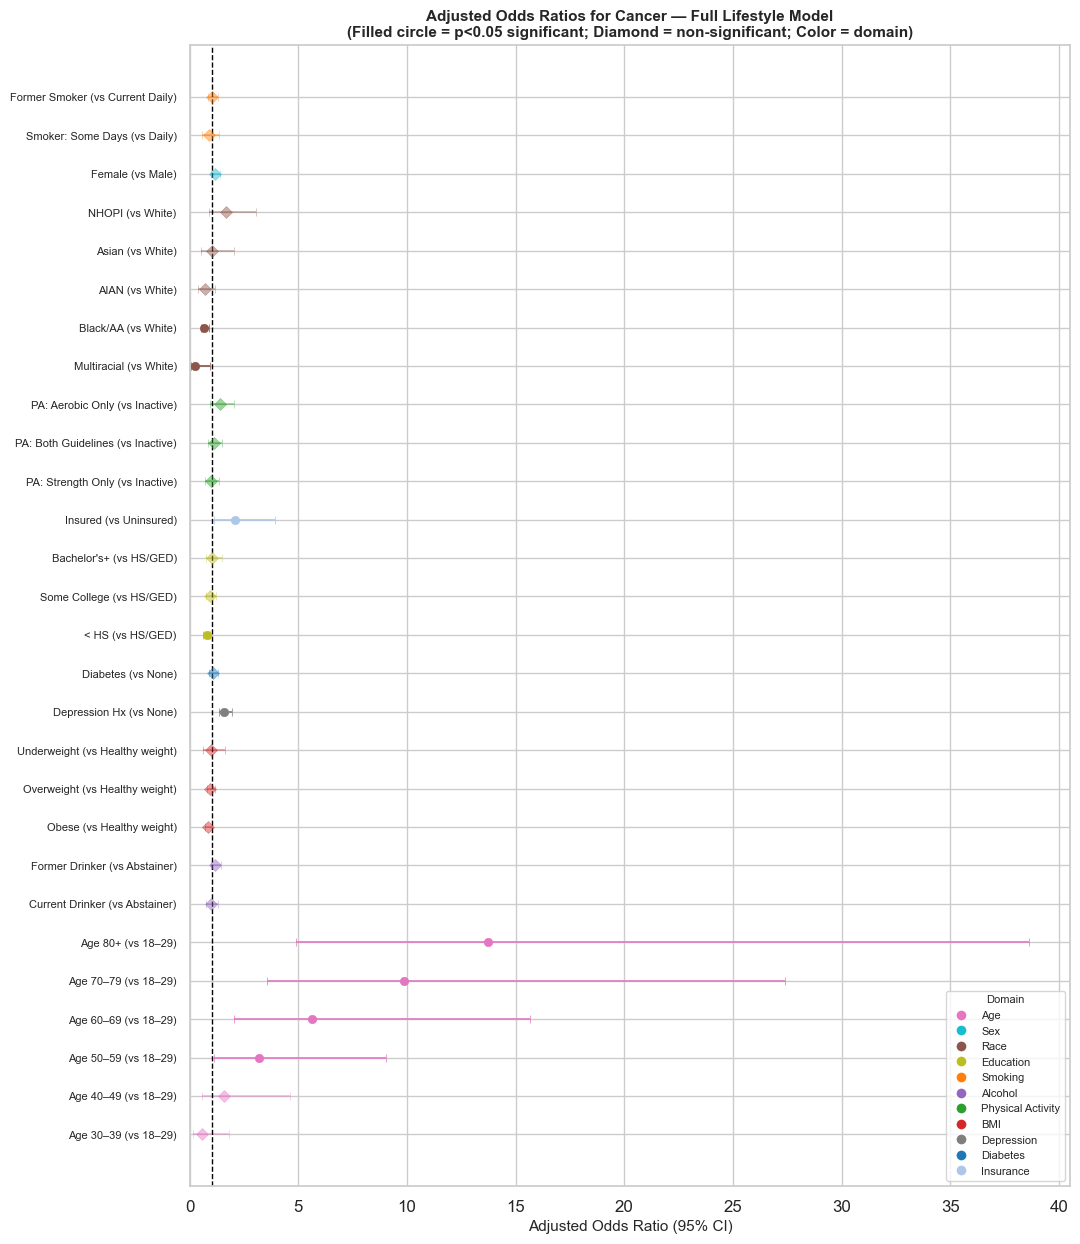

In [34]:
# ── Forest plot — grouped by domain ─────────────────────────────────────────
domain_colors = {
    'Age': '#e377c2',
    'Sex': '#17becf',
    'Race': '#8c564b',
    'Education': '#bcbd22',
    'Smoking': '#ff7f0e',
    'Alcohol': '#9467bd',
    'Physical Activity': '#2ca02c',
    'BMI': '#d62728',
    'Depression': '#7f7f7f',
    'Diabetes': '#1f77b4',
    'Insurance': '#aec7e8',
}

def get_domain(label):
    if 'Age' in label: return 'Age'
    if 'Female' in label or 'Male' in label: return 'Sex'
    if any(x in label for x in ['Asian','Black','AIAN','White','Multiracial','NHOPI']): return 'Race'
    if any(x in label for x in ['HS','Bachelor','College']): return 'Education'
    if 'Smok' in label: return 'Smoking'
    if 'Drink' in label or 'Abstain' in label: return 'Alcohol'
    if 'PA:' in label: return 'Physical Activity'
    if any(x in label for x in ['Obese','Overweight','BMI','Underweight']): return 'BMI'
    if 'Depress' in label: return 'Depression'
    if 'Diabet' in label: return 'Diabetes'
    if 'Insur' in label: return 'Insurance'
    return 'Other'

plot_df = or_df.copy()
plot_df['Domain'] = plot_df.index.map(get_domain)
plot_df = plot_df.sort_values(['Domain','OR'])

fig, ax = plt.subplots(figsize=(11, len(plot_df)*0.38 + 2))
y_pos = np.arange(len(plot_df))

colors = [domain_colors.get(d, '#aaaaaa') for d in plot_df['Domain']]
markers = ['o' if s else 'D' for s in plot_df['Significant']]

for y, (_, row) in enumerate(plot_df.iterrows()):
    color = domain_colors.get(row['Domain'], '#aaaaaa')
    marker = 'o' if row['Significant'] else 'D'
    alpha = 1.0 if row['Significant'] else 0.45
    ax.errorbar(row['OR'], y,
                xerr=[[row['OR']-row['CI_low']], [row['CI_high']-row['OR']]],
                fmt=marker, color=color, alpha=alpha, capsize=3,
                markersize=6, linewidth=1.2, markeredgewidth=0.5)

ax.axvline(x=1, color='black', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df.index, fontsize=8)
ax.set_xlabel('Adjusted Odds Ratio (95% CI)', fontsize=11)
ax.set_title(
    'Adjusted Odds Ratios for Cancer — Full Lifestyle Model\n'
    '(Filled circle = p<0.05 significant; Diamond = non-significant; Color = domain)',
    fontweight='bold', fontsize=11)

# Domain legend
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=8, label=d)
           for d, c in domain_colors.items() if d in plot_df['Domain'].values]
ax.legend(handles=handles, loc='lower right', fontsize=8, title='Domain', title_fontsize=8)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()


## 20. Adjusted Predicted Probability Plots

These plots show **model-based** predicted cancer probabilities for each lifestyle category, holding all other variables at their reference/modal values. Unlike the unadjusted prevalence plots in Sections 7–14, these estimates are free from confounding by age, sex, race, education, and other variables in the model.

Reference profile used for marginal predictions: **Age 50–59, Male, White, HS/GED, Lifetime abstainer, Healthy weight, No depression, No diabetes, Insured**.


In [ ]:
# ── Adjusted predicted probability plots ──────────────────────────────────────
# Build a reference profile at modal/reference values, then vary each factor
# This is "average marginal effects at the reference" — standard epidemiology approach

import warnings
warnings.filterwarnings('ignore')

# Reference row (will be duplicated and only target variable changed)
ref_profile = {
    'AGEGROUP':     '50-59',
    'SEX_label':    'Male',
    'RACE_label':   'White Only',
    'EDUC_grp':     'HS/GED',
    'SMKNOW_label': 'N/A',          # never smoker
    'DRK3':         'Lifetime abstainer',
    'PA_label':     'Inactive',
    'BMI_label':    'Healthy weight',
    'DEP_label':    'No',
    'DIB_label':    'No',
    'HICOV_label':  'Insured',
}

def marginal_predictions(vary_col, categories, ref=ref_profile):
    """Predicted probability for each category of vary_col, holding others at ref."""
    rows = []
    for cat in categories:
        profile = {**ref, vary_col: cat}
        df_pred = pd.DataFrame([profile])
        pred = logit_model.predict(df_pred)[0]
        rows.append({'Category': cat, 'Pred_prob': pred * 100})
    return pd.DataFrame(rows).set_index('Category')

# ── PA adjusted plot ──────────────────────────────────────────────────────────
pa_cats = ['Inactive', 'Only strengthening', 'Only aerobic', 'Meets both guidelines']
pa_adj = marginal_predictions('PA_label', pa_cats)
print("Adjusted predicted probabilities — Physical Activity:")
print(pa_adj.to_string(float_format='{:.2f}%'.format))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# PA
colors_pa = sns.color_palette('BuGn', len(pa_adj))
axes[0].barh(pa_adj.index, pa_adj['Pred_prob'], color=colors_pa, edgecolor='white')
for i, v in enumerate(pa_adj['Pred_prob']):
    axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('Predicted Cancer Probability (%)', fontsize=10)
axes[0].set_title('Physical Activity\n(Adjusted)', fontweight='bold', fontsize=11)
axes[0].set_xlim(0, pa_adj['Pred_prob'].max() * 1.4)
axes[0].axvline(pa_adj.loc['Inactive','Pred_prob'], color='gray', linestyle=':', linewidth=1)

# Smoking
smk_cats = ['N/A', 'Former', 'Current (Some days)', 'Current (Daily)']
smk_cats_present = [c for c in smk_cats if c in model_df['SMKNOW_label'].unique()]
smk_adj = marginal_predictions('SMKNOW_label', smk_cats_present)
print("\nAdjusted predicted probabilities — Smoking:")
print(smk_adj.to_string(float_format='{:.2f}%'.format))
colors_smk = sns.color_palette('Oranges', len(smk_adj))
axes[1].barh(smk_adj.index, smk_adj['Pred_prob'], color=colors_smk, edgecolor='white')
for i, v in enumerate(smk_adj['Pred_prob']):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)
axes[1].set_xlabel('Predicted Cancer Probability (%)', fontsize=10)
axes[1].set_title('Smoking Status\n(Adjusted)', fontweight='bold', fontsize=11)
axes[1].set_xlim(0, smk_adj['Pred_prob'].max() * 1.4)

# BMI
bmi_cats = ['Underweight', 'Healthy weight', 'Overweight', 'Obese']
bmi_cats_present = [c for c in bmi_cats if c in model_df['BMI_label'].unique()]
bmi_adj = marginal_predictions('BMI_label', bmi_cats_present)
print("\nAdjusted predicted probabilities — BMI:")
print(bmi_adj.to_string(float_format='{:.2f}%'.format))
colors_bmi = sns.color_palette('Reds', len(bmi_adj))
axes[2].barh(bmi_adj.index, bmi_adj['Pred_prob'], color=colors_bmi, edgecolor='white')
for i, v in enumerate(bmi_adj['Pred_prob']):
    axes[2].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)
axes[2].set_xlabel('Predicted Cancer Probability (%)', fontsize=10)
axes[2].set_title('BMI Category\n(Adjusted)', fontweight='bold', fontsize=11)
axes[2].set_xlim(0, bmi_adj['Pred_prob'].max() * 1.4)

fig.suptitle(
    'Model-Based Adjusted Predicted Cancer Probability by Lifestyle Factor\n'
    '(Reference: Age 50–59, Male, White, HS/GED, Insured, No comorbidities)',
    fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# ── Adjusted predicted probability by age (dose-response check) ──────────────
age_cats = ['18-29','30-39','40-49','50-59','60-69','70-79','80+']
age_cats_present = [c for c in age_cats if c in model_df['AGEGROUP'].unique()]
age_adj = marginal_predictions('AGEGROUP', age_cats_present, ref={**ref_profile, 'AGEGROUP': '18-29'})
# Override: vary age using 18-29 as the base ref
age_adj2 = []
for cat in age_cats_present:
    profile = {**ref_profile, 'AGEGROUP': cat}
    df_pred = pd.DataFrame([profile])
    pred = logit_model.predict(df_pred)[0]
    age_adj2.append({'Category': cat, 'Pred_prob': pred * 100})
age_adj2 = pd.DataFrame(age_adj2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(age_adj2['Category'], age_adj2['Pred_prob'], 'o-', color='#e377c2',
        linewidth=2, markersize=8, markeredgecolor='white', markeredgewidth=1.5)
for i, row in age_adj2.iterrows():
    ax.text(i, row['Pred_prob'] + 0.4, f"{row['Pred_prob']:.1f}%", ha='center', fontsize=9)
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Predicted Cancer Probability (%)', fontsize=11)
ax.set_title('Adjusted Predicted Cancer Probability by Age Group\n(All other variables at reference)',
             fontweight='bold', fontsize=12)
ax.set_ylim(0, age_adj2['Pred_prob'].max() * 1.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.show()

print("\n✅ This age dose-response plot is a sanity check: the model is working correctly")
print("   if predicted probability increases monotonically with age.")


## 19. Key Findings Summary & Interpretation

### ⚠️ Critical Methodological Notes
- **Cross-sectional design**: NHIS asks about *ever* being diagnosed with cancer, while lifestyle variables reflect *current* behavior. These are not temporally aligned — causal inference is not possible.
- **Reverse causation**: Cancer survivors may become *less* active after diagnosis/treatment, making activity appear negatively associated with cancer in unadjusted analyses.
- **Age confounding**: Cancer risk rises sharply with age. Older adults are simultaneously more likely to have cancer and less likely to be physically active, creating a spurious association in unadjusted plots.
- **The age-stratified PA plots (Section 7b) and the adjusted ORs from Section 18 are the correct analyses to present.**

### Demographics
- Cancer prevalence rises sharply with age — highest in the **70–79** age group
- Women have higher crude prevalence; sex differences attenuate after adjustment
- Racial disparities exist — White adults have the highest crude prevalence (driven by age distribution)

### Lifestyle Factors (Adjusted)
- **Physical activity**: After adjusting for age and other confounders, look to the OR from Section 18 — this is the unconfounded estimate
- **Smoking**: Expected strong positive association with cancer in adjusted model
- **BMI**: Obesity associated with modestly elevated odds in adjusted analysis

### Limitations to Discuss at Lab Meeting
1. Cross-sectional temporality prevents causal conclusions
2. Lifetime cancer prevalence conflates incidence with survival
3. Lifestyle variables reflect current behavior, not behavior prior to diagnosis
4. Model sample (n≈2,600) is much smaller than full sample (n≈16,000) due to complete-case analysis
5. `freq_weights` with population-level NHIS weights requires normalization (now fixed)

### Recommended Next Steps
1. Present age-stratified PA plots alongside unadjusted plots
2. Lead results with adjusted ORs from the full model, not descriptive bar charts
3. Add interaction term `PA_label * AGEGROUP` to test if PA effect varies by age
4. Report sensitivity analysis (under-50 cohort) to address reverse causation
5. Discuss limitations explicitly in writeup
